time :  636.458 continuityError :  0.000278946779


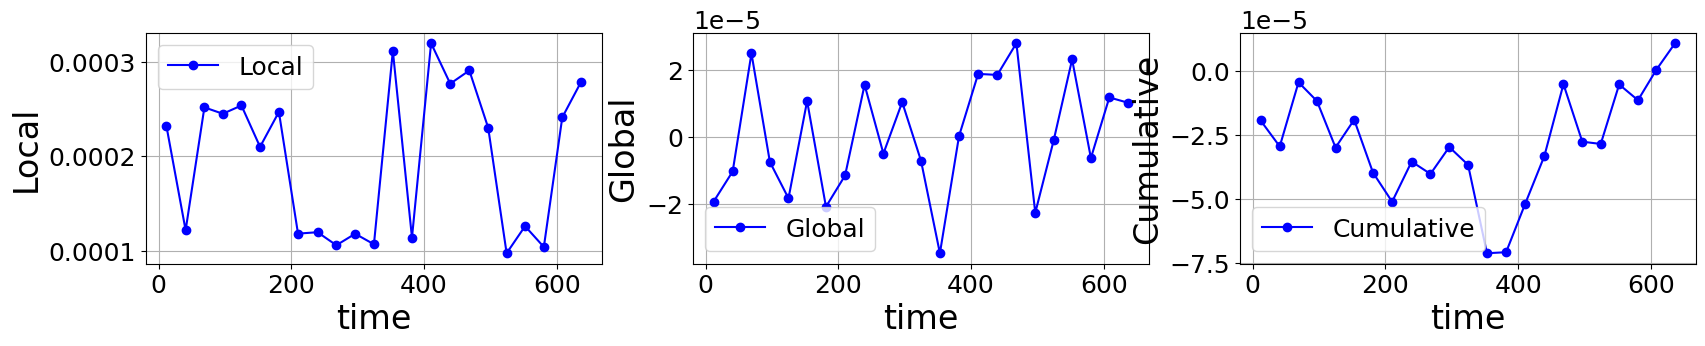

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

def graph_func(df_continuityError, imin, imax, iposi,icol):
    plt.subplot(imin,imax,iposi)
    plt.plot(df_continuityError['time'],df_continuityError[icol],linestyle='solid',color='b',marker="o",label=icol)
    plt.xlabel('time')
    plt.ylabel(icol)
    plt.legend()
    plt.grid()

def df_continuityError_func(dir_):
    data_continuityError = np.loadtxt(f'./postProcessing/continuityError1/{dir_}/continuityError.dat')
    df_continuityError = pd.DataFrame(data_continuityError, columns=['time','Local','Global','Cumulative'])  
    return df_continuityError

def df_concat(dir_List):
    df = pd.DataFrame()
    for dir_ in dir_List:
        try:
            df_ = df_continuityError_func(dir_)
            df = pd.concat([df, df_])
        except Exception:
            print("Empty")
        
    return df

dir_List = os.listdir('./postProcessing/continuityError1')
df_continuityError = df_concat(dir_List)

plt.figure(figsize=(20,3))
graph_func(df_continuityError, 1,3,1,'Local')
graph_func(df_continuityError, 1,3,2,'Global')
graph_func(df_continuityError, 1,3,3,'Cumulative')

print('time : ',df_continuityError['time'].iloc[-1], 'continuityError : ', df_continuityError['Local'].iloc[-1])

df_continuityError.head()
plt.savefig("001_continuityError1.png",bbox_inches='tight')

# 残差

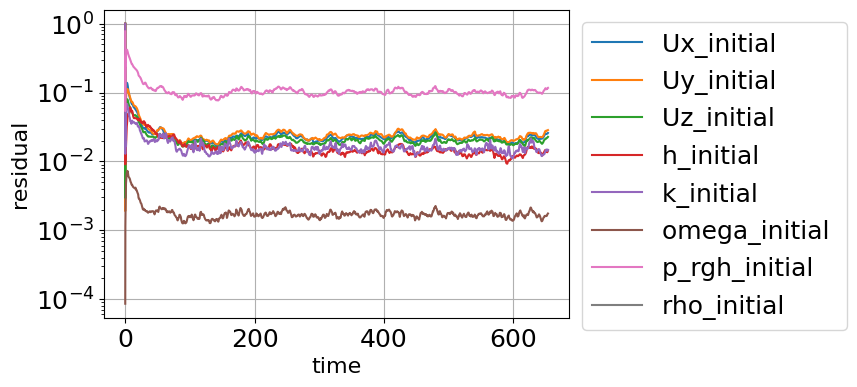

In [27]:
import pandas as pd
import matplotlib.pyplot as plt


def graph_layout():
    plt.grid()
    plt.legend(loc='best',bbox_to_anchor=(1, 1))
    plt.yscale('log')
    plt.xlabel('time', fontsize=16)
    plt.ylabel('residual', fontsize=16)

def df_residual_func(dir_):
    df_residual = pd.read_table(f'./postProcessing/residuals/{dir_}/solverInfo.dat',skiprows=1)
    df_residual = pd.DataFrame(df_residual)
    return df_residual

def df_concat(dir_List):
    df = pd.DataFrame()
    for dir_ in dir_List:
        try:
            df_ = df_residual_func(dir_)
            df = pd.concat([df, df_])
        except Exception:
            print("Empty")
        
    return df

dir_List = os.listdir('./postProcessing/residuals')
df_residual = df_concat(dir_List)

initial_residial = [data for data in df_residual.columns if "initial" in data]
final_residial = [data for data in df_residual.columns if "final" in data]
df_residual.plot(x=df_residual.columns[0],y=initial_residial, figsize=(6, 4))
graph_layout()

plt.savefig("002_residual.png",bbox_inches='tight')

# 体積流量 

inlet_phi = -135000
outlet_phi = 135000
floodOutlet_press_2-4_0 = Empty DataFrame
Columns: [# Time          , sum(phi), sum(phi)(L/min)]
Index: []


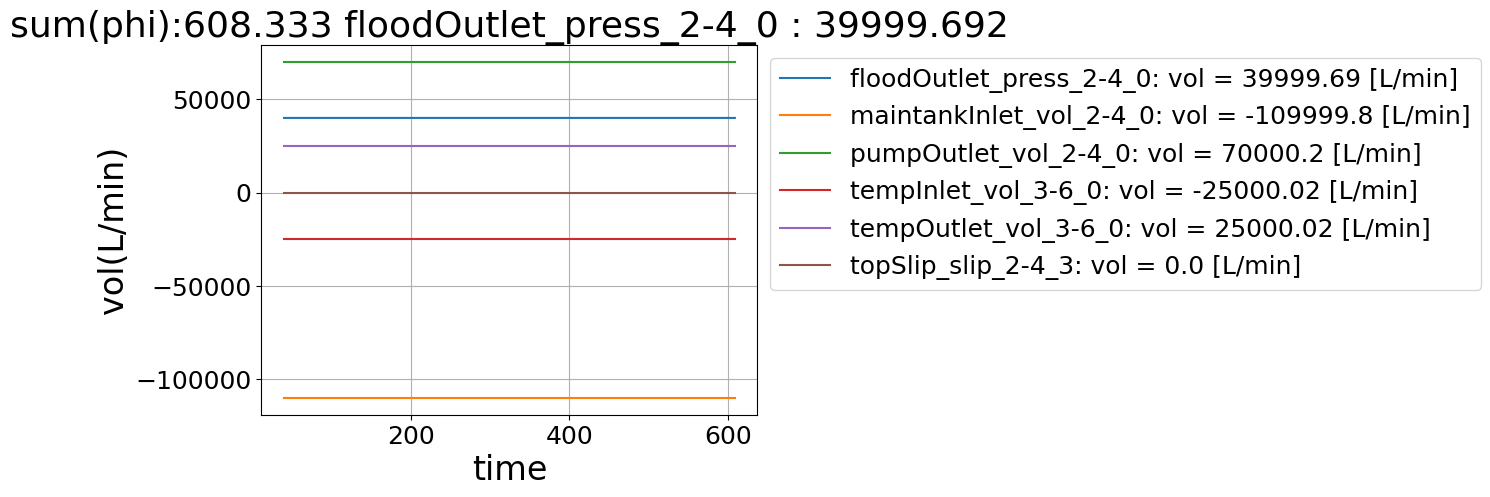

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def graph_surfaceField(df_phi, patchName):
    sum_phi = round(df_phi['sum(phi)(L/min)'].iloc[-1],2)
    plt.plot(df_phi[df_phi.columns[0]],df_phi['sum(phi)(L/min)'],
            label=f'{patchName}: vol = {str(sum_phi)} [L/min]')
    plt.xlabel('time')
    plt.ylabel('vol(L/min)')
    plt.legend(loc='best',bbox_to_anchor=(1, 1))
    if "flood" in patchName:
        plt.title(f'sum(phi):{df_phi[df_phi.columns[0]].iloc[-1]} {patchName} : {round(df_phi["sum(phi)(L/min)"].iloc[-1],3)}')
def sum_phi_func(df_phi):
    sum_phi = round(df_phi['sum(phi)(L/min)'].iloc[-1])
    return sum_phi

def df_phi_func(dir_, patchName):
    df_phi = pd.read_table(f'./postProcessing/{patchName}/{dir_}/surfaceFieldValue.dat',skiprows=4)
    df_phi = pd.DataFrame(df_phi)
    df_phi['sum(phi)(L/min)'] = df_phi['sum(phi)']*1000*60

    return df_phi

def df_concat(dir_List, patchName):
    df = pd.DataFrame()
    for dir_ in dir_List:
        try:
            df_ = df_phi_func(dir_, patchName)
            df = pd.concat([df, df_])
        except Exception:
            print("Empty")
        
    return df

surfaceField_list = [patchName for patchName in os.listdir('./postProcessing') if len(patchName.split('_'))>=3]

inlet_phi = 0
outlet_phi = 0
    
for patchName in surfaceField_list:
    dir_List = os.listdir(f'./postProcessing/{patchName}')
    df_phi = df_concat(dir_List, patchName)
    graph_surfaceField(df_phi, patchName)
    sum_phi = sum_phi_func(df_phi)
    if sum_phi <0:
        inlet_phi +=sum_phi

    else:
        outlet_phi +=sum_phi

print(f'inlet_phi = {inlet_phi}')
print(f'outlet_phi = {outlet_phi}')
df_concat


patchName_press =  [patch for patch in os.listdir(f'./postProcessing') if "flood" in patch][0]
vol = 25
small = 1e-5*1000*60*2
dir_List = os.listdir(f'./postProcessing/{patchName_press}')
df_press = df_concat(dir_List, patchName_press)
print(f"{patchName_press} = {df_press[(df_press['sum(phi)(L/min)'] >= vol-small) & (df_press['sum(phi)(L/min)'] <= vol +small)]}")

plt.grid()

plt.savefig("003_surfaceFieldValue.png",bbox_inches='tight')

# 温度

C:\Users\kusum\AppData\Local\Temp\ipykernel_21404\1131182462.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, comment="#", delim_whitespace=True)


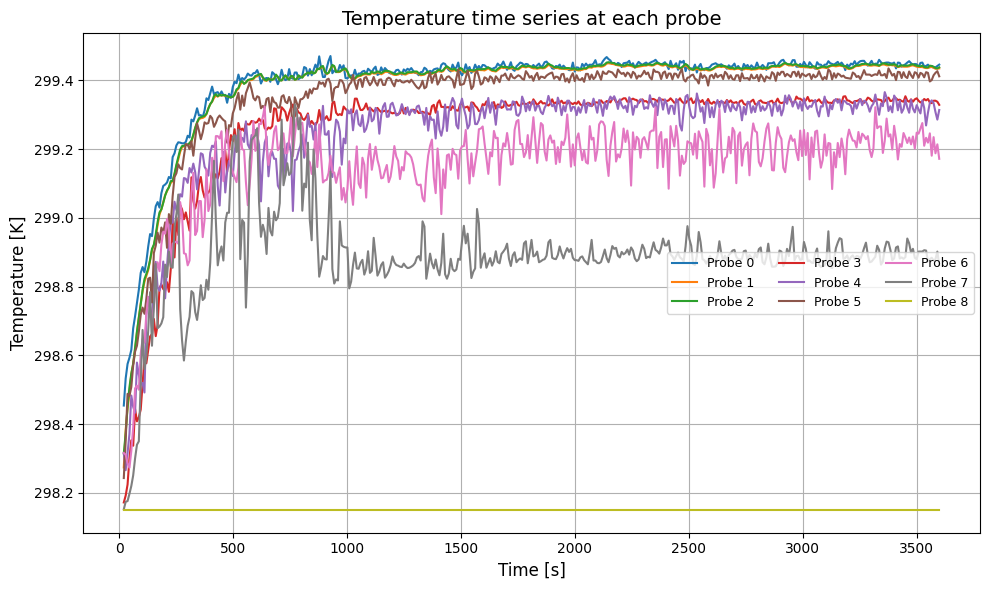

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# ===== 読み込むファイル =====
file_path = "postProcessing/probes/10/T"  # 必要に応じて変更

# ===== ファイル読み込み =====
df = pd.read_csv(file_path, comment="#", delim_whitespace=True)

# 列名設定（最初の列が Time、それ以降が Probe 0〜）
df.columns = ["Time"] + [f"Probe {i}" for i in range(df.shape[1]-1)]

# ===== グラフ描画 =====
plt.figure(figsize=(10, 6))

for col in df.columns[1:]:
    plt.plot(df["Time"], df[col], label=col)

plt.xlabel("Time [s]", fontsize=12)
plt.ylabel("Temperature [K]", fontsize=12)
plt.title("Temperature time series at each probe", fontsize=14)
plt.legend(ncol=3, fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\kusum\AppData\Local\Temp\ipykernel_34048\3857426182.py:24: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  first_df = pd.read_csv(time_files[0][1], comment="#", delim_whitespace=True, header=None, engine="python")


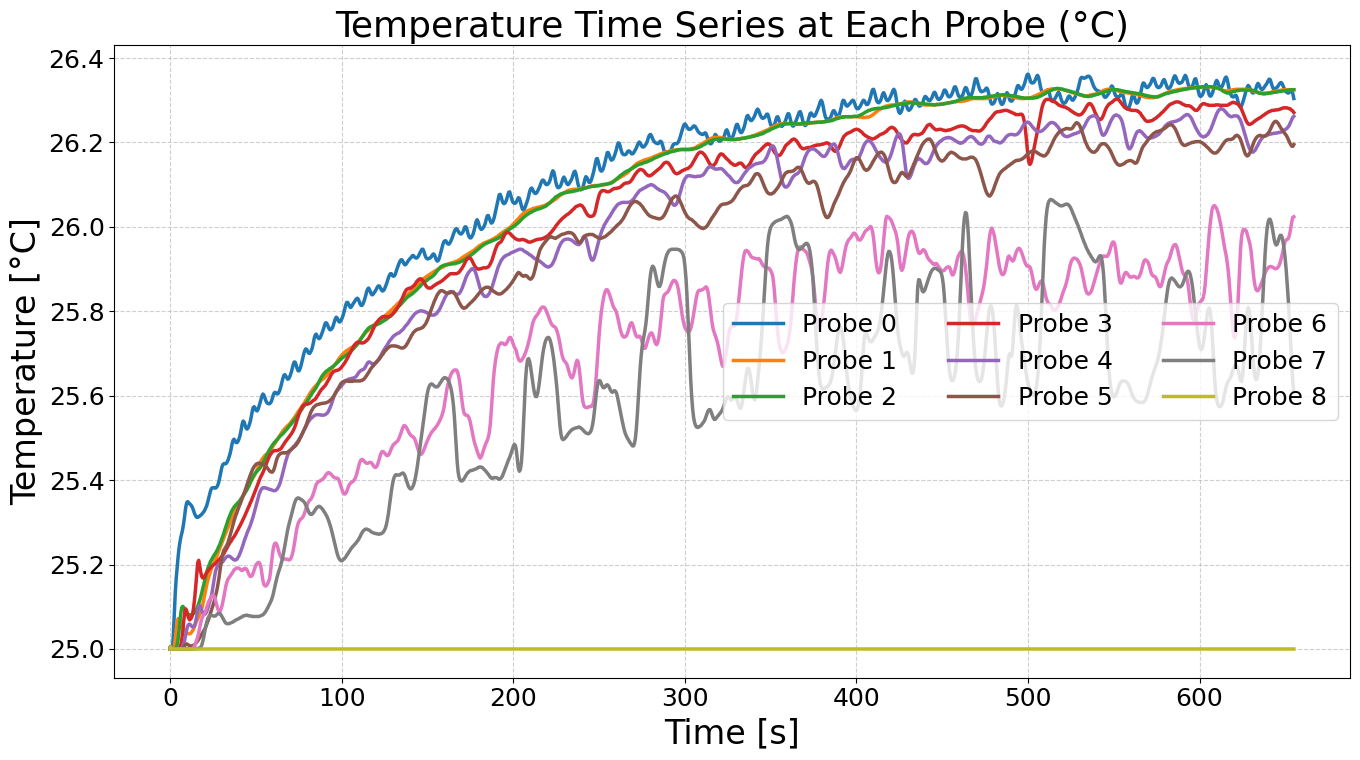

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re

# ===== 基本設定 =====
base_dir = Path("postProcessing/probes")   # <時刻>/T が並ぶ親ディレクトリ
quantity = "T"                             # 読むファイル名
smooth_window = 1                         # 移動平均のウィンドウ幅（0 or 1 で無効）

# ===== Tファイルの列挙（0, 10, 20, ... を数値昇順で）=====
time_files = []
for p in base_dir.glob("*"):
    if p.is_dir() and re.fullmatch(r"\d+", p.name):
        f = p / quantity
        if f.is_file():
            time_files.append((int(p.name), f))
time_files.sort(key=lambda x: x[0])

if not time_files:
    raise FileNotFoundError(f"No '{quantity}' files under {base_dir}/<time>/")

# ===== 1つ目で列数（= Probe数+1）を決定 =====
first_df = pd.read_csv(time_files[0][1], comment="#", delim_whitespace=True, header=None, engine="python")
ncols = first_df.shape[1]
frames = [first_df]

# 残りも読む（列数が違う場合は安全側で合わせる）
for _, f in time_files[1:]:
    df_i = pd.read_csv(f, comment="#", delim_whitespace=True, header=None, engine="python")
    if df_i.shape[1] < ncols:
        # 不足分は NaN 列を追加
        for _ in range(ncols - df_i.shape[1]):
            df_i[df_i.shape[1]] = pd.NA
    elif df_i.shape[1] > ncols:
        df_i = df_i.iloc[:, :ncols]
    frames.append(df_i)

# ===== 結合 → 列名付与 → 時間ソート＆重複除去 =====
df = pd.concat(frames, ignore_index=True)
df.columns = ["Time"] + [f"Probe {i}" for i in range(ncols - 1)]
df = df.sort_values("Time").drop_duplicates(subset="Time", keep="last").reset_index(drop=True)

# ===== Kelvin → Celsius =====
for col in df.columns[1:]:
    df[col] = df[col] - 273.15

# ===== 平滑化（移動平均） =====
if smooth_window and smooth_window > 1:
    df_smooth = df.copy()
    for col in df.columns[1:]:
        df_smooth[col] = df[col].rolling(window=smooth_window, center=True, min_periods=1).mean()
else:
    df_smooth = df

# ===== フォント設定（大きめ） =====
plt.rcParams.update({
    "font.size": 20,
    "axes.labelsize": 24,
    "axes.titlesize": 26,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
})

# ===== プロット =====
plt.figure(figsize=(14, 8))
for col in df.columns[1:]:
    plt.plot(df["Time"], df_smooth[col], linewidth=2.5, label=col)

plt.xlabel("Time [s]")
plt.ylabel("Temperature [°C]")
title = "Temperature Time Series at Each Probe (°C)"
if smooth_window and smooth_window > 1:
    title += f"  [moving average: {smooth_window}]"
plt.title(title)
plt.legend(ncol=3, loc="best")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# （任意）結合結果を保存したい場合：
# df.to_csv(base_dir / "_combined_T_C.csv", index=False)


C:\Users\kusum\AppData\Local\Temp\ipykernel_34048\135765717.py:25: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  first_df = pd.read_csv(time_files[0][1], comment="#", delim_whitespace=True, header=None, engine="python")
C:\Users\kusum\AppData\Local\Temp\ipykernel_34048\135765717.py:29: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_i = pd.read_csv(f, comment="#", delim_whitespace=True, header=None, engine="python")


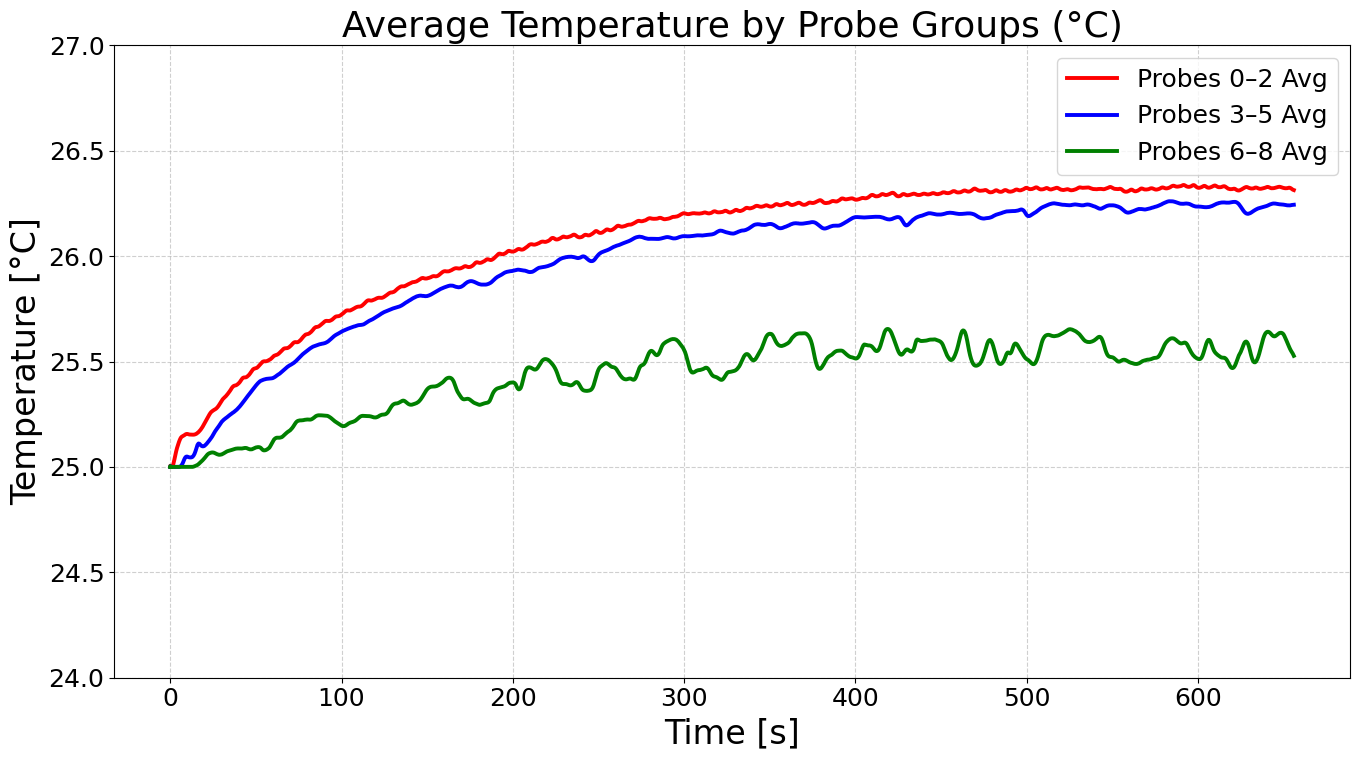

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re

# ===== データ設定 =====
base_dir = Path("postProcessing/probes")
quantity = "T"
smooth_window = 1  # 移動平均ウィンドウ幅

# ===== ファイル探索 =====
time_files = []
for p in base_dir.glob("*"):
    if p.is_dir() and re.fullmatch(r"\d+", p.name):
        f = p / quantity
        if f.is_file():
            time_files.append((int(p.name), f))
time_files.sort(key=lambda x: x[0])

if not time_files:
    raise FileNotFoundError(f"No '{quantity}' files under {base_dir}/<time>/")

# ===== 結合処理 =====
frames = []
first_df = pd.read_csv(time_files[0][1], comment="#", delim_whitespace=True, header=None, engine="python")
ncols = first_df.shape[1]

for _, f in time_files:
    df_i = pd.read_csv(f, comment="#", delim_whitespace=True, header=None, engine="python")
    if df_i.shape[1] < ncols:
        for _ in range(ncols - df_i.shape[1]):
            df_i[df_i.shape[1]] = pd.NA
    elif df_i.shape[1] > ncols:
        df_i = df_i.iloc[:, :ncols]
    frames.append(df_i)

df = pd.concat(frames, ignore_index=True)
df.columns = ["Time"] + [f"Probe {i}" for i in range(df.shape[1] - 1)]
df = df.sort_values("Time").drop_duplicates(subset="Time", keep="last").reset_index(drop=True)

# ===== Kelvin → Celsius =====
for col in df.columns[1:]:
    df[col] = df[col] - 273.15

# ===== 平滑化 =====
if smooth_window > 1:
    df_smooth = df.copy()
    for col in df.columns[1:]:
        df_smooth[col] = df[col].rolling(window=smooth_window, center=True, min_periods=1).mean()
else:
    df_smooth = df

# ===== グループ平均 =====
group1 = df_smooth[["Probe 0", "Probe 1", "Probe 2"]].mean(axis=1)
group2 = df_smooth[["Probe 3", "Probe 4", "Probe 5"]].mean(axis=1)
group3 = df_smooth[["Probe 6", "Probe 7", "Probe 8"]].mean(axis=1)

# ===== プロット設定 =====
plt.rcParams.update({
    "font.size": 20,
    "axes.labelsize": 24,
    "axes.titlesize": 26,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
})

plt.figure(figsize=(14, 8))

# ---- 赤・青・緑の順で描画 ----
plt.plot(df_smooth["Time"], group1, color="red",   linewidth=2.8, label="Probes 0–2 Avg")
plt.plot(df_smooth["Time"], group2, color="blue",  linewidth=2.8, label="Probes 3–5 Avg")
plt.plot(df_smooth["Time"], group3, color="green", linewidth=2.8, label="Probes 6–8 Avg")

plt.xlabel("Time [s]")
plt.ylabel("Temperature [°C]")
plt.title("Average Temperature by Probe Groups (°C)")

plt.ylim(24, 27)  # ← 縦軸範囲固定
plt.legend(loc="best")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


# OpenModelicaの結果ファイル読み込みとグラフ描画

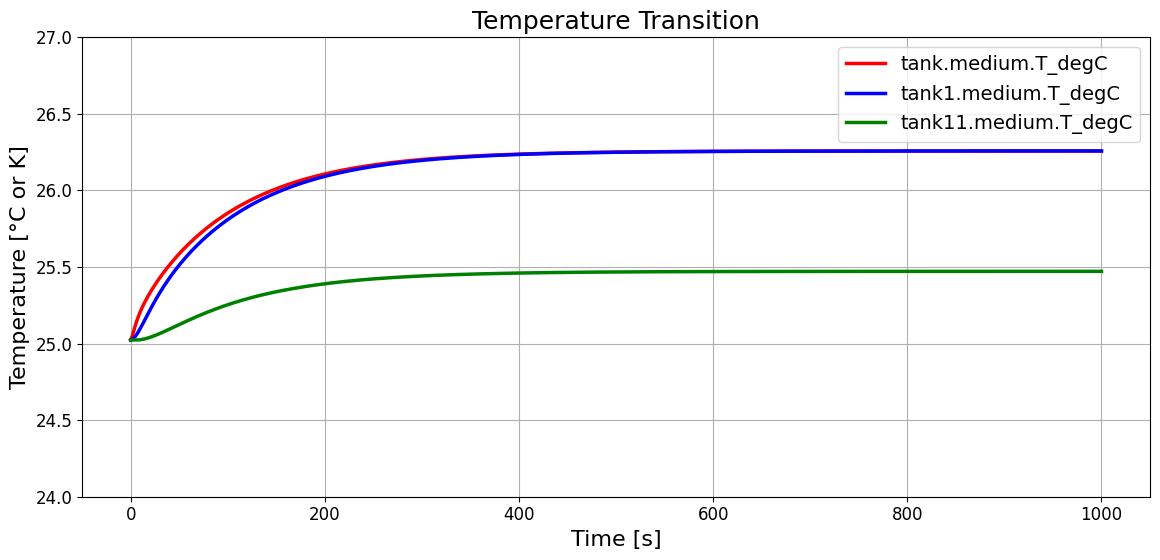

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ====== データ読み込み ======
file_path = Path("./OM_csv/exportedVariables.csv")  # 実際のファイル名に置き換えてください
df = pd.read_csv(file_path)

# ====== グラフ設定 ======
plt.figure(figsize=(12, 6))

plt.plot(df["time"], df["tank.medium.T_degC"], color="red", linewidth=2.5, label="tank.medium.T_degC")
plt.plot(df["time"], df["tank1.medium.T_degC"], color="blue", linewidth=2.5, label="tank1.medium.T_degC")
plt.plot(df["time"], df["tank11.medium.T_degC"], color="green", linewidth=2.5, label="tank11.medium.T_degC")

# ====== 軸・凡例・フォント設定 ======
plt.xlabel("Time [s]", fontsize=16)
plt.ylabel("Temperature [°C or K]", fontsize=16)
plt.title("Temperature Transition", fontsize=18)
plt.legend(fontsize=14)
plt.grid(True)

# 縦軸の範囲をデータから自動で少し余裕をもたせて設定
plt.ylim(24, 27)  # ← 縦軸範囲固定

# ====== 体裁 ======
plt.tick_params(labelsize=12)
plt.tight_layout()
plt.show()


C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\3174162496.py:20: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  first_df = pd.read_csv(time_files[0][1], comment="#", delim_whitespace=True, header=None, engine="python")
C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\3174162496.py:23: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_i = pd.read_csv(f, comment="#", delim_whitespace=True, header=None, engine="python")


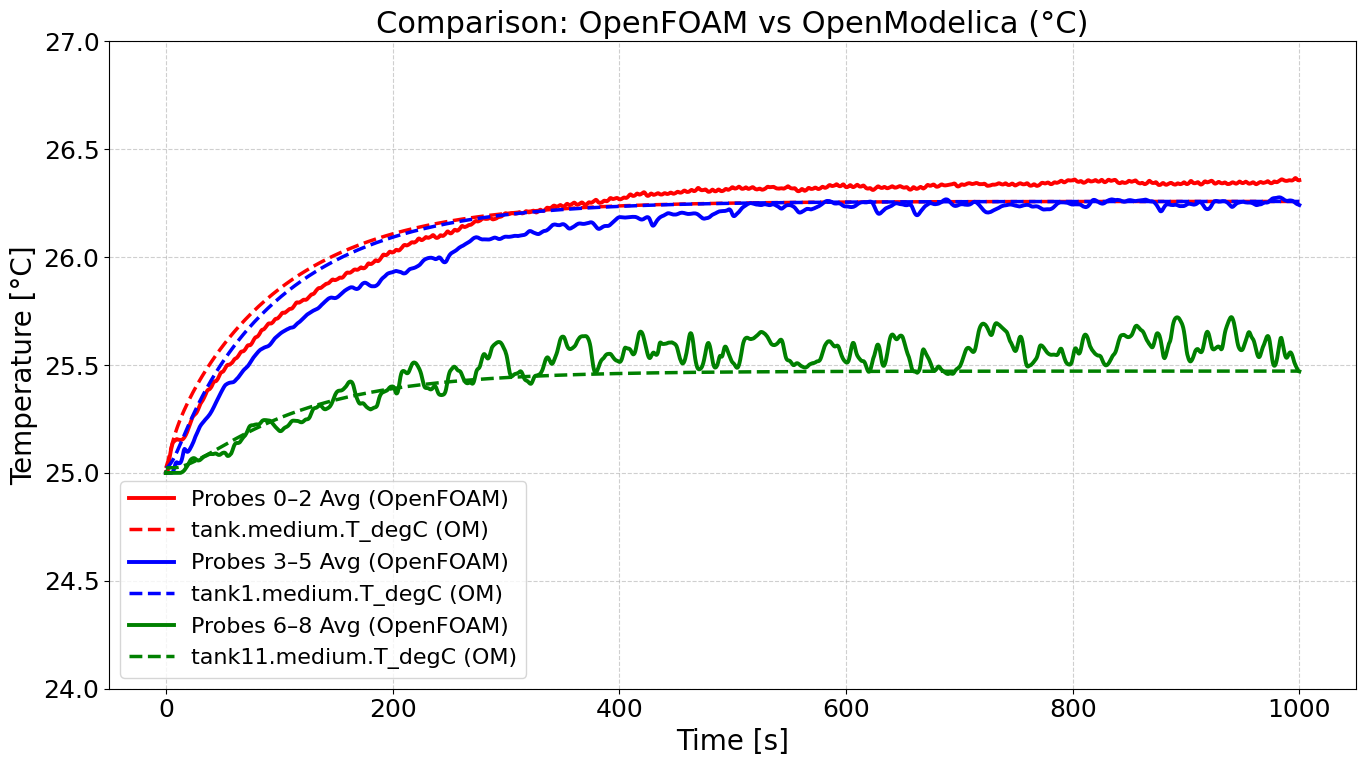

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re

# ====== OpenFOAM データ ======
base_dir = Path("postProcessing/probes")
quantity = "T"
smooth_window = 1

time_files = []
for p in base_dir.glob("*"):
    if p.is_dir() and re.fullmatch(r"\d+", p.name):
        f = p / quantity
        if f.is_file():
            time_files.append((int(p.name), f))
time_files.sort(key=lambda x: x[0])

frames = []
first_df = pd.read_csv(time_files[0][1], comment="#", delim_whitespace=True, header=None, engine="python")
ncols = first_df.shape[1]
for _, f in time_files:
    df_i = pd.read_csv(f, comment="#", delim_whitespace=True, header=None, engine="python")
    if df_i.shape[1] < ncols:
        for _ in range(ncols - df_i.shape[1]):
            df_i[df_i.shape[1]] = pd.NA
    elif df_i.shape[1] > ncols:
        df_i = df_i.iloc[:, :ncols]
    frames.append(df_i)
df_foam = pd.concat(frames, ignore_index=True)
df_foam.columns = ["Time"] + [f"Probe {i}" for i in range(df_foam.shape[1] - 1)]
df_foam = df_foam.sort_values("Time").drop_duplicates(subset="Time", keep="last").reset_index(drop=True)

# Kelvin → Celsius
for col in df_foam.columns[1:]:
    df_foam[col] = df_foam[col] - 273.15

# グループ平均
group1 = df_foam[["Probe 0", "Probe 1", "Probe 2"]].mean(axis=1)
group2 = df_foam[["Probe 3", "Probe 4", "Probe 5"]].mean(axis=1)
group3 = df_foam[["Probe 6", "Probe 7", "Probe 8"]].mean(axis=1)

# ====== OpenModelica データ ======
df_om = pd.read_csv(Path("./OM_csv/exportedVariables.csv"))

# ====== グラフ設定 ======
plt.rcParams.update({
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 22,
    "legend.fontsize": 16,
})

plt.figure(figsize=(14, 8))

# ---- 赤：Probes 0–2 vs tank.medium.T_degC ----
plt.plot(df_foam["Time"], group1, color="red", linewidth=2.8, label="Probes 0–2 Avg (OpenFOAM)")
plt.plot(df_om["time"], df_om["tank.medium.T_degC"], color="red", linestyle="--", linewidth=2.5, label="tank.medium.T_degC (OM)")

# ---- 青：Probes 3–5 vs tank1.medium.T_degC ----
plt.plot(df_foam["Time"], group2, color="blue", linewidth=2.8, label="Probes 3–5 Avg (OpenFOAM)")
plt.plot(df_om["time"], df_om["tank1.medium.T_degC"], color="blue", linestyle="--", linewidth=2.5, label="tank1.medium.T_degC (OM)")

# ---- 緑：Probes 6–8 vs tank11.medium.T_degC ----
plt.plot(df_foam["Time"], group3, color="green", linewidth=2.8, label="Probes 6–8 Avg (OpenFOAM)")
plt.plot(df_om["time"], df_om["tank11.medium.T_degC"], color="green", linestyle="--", linewidth=2.5, label="tank11.medium.T_degC (OM)")

# ====== 軸設定 ======
plt.xlabel("Time [s]")
plt.ylabel("Temperature [°C]")
plt.title("Comparison: OpenFOAM vs OpenModelica (°C)")

plt.ylim(24, 27)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="best")
plt.tight_layout()
plt.show()


C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\516666000.py:20: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  first_df = pd.read_csv(time_files[0][1], comment="#", delim_whitespace=True, header=None, engine="python")
C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\516666000.py:23: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_i = pd.read_csv(f, comment="#", delim_whitespace=True, header=None, engine="python")


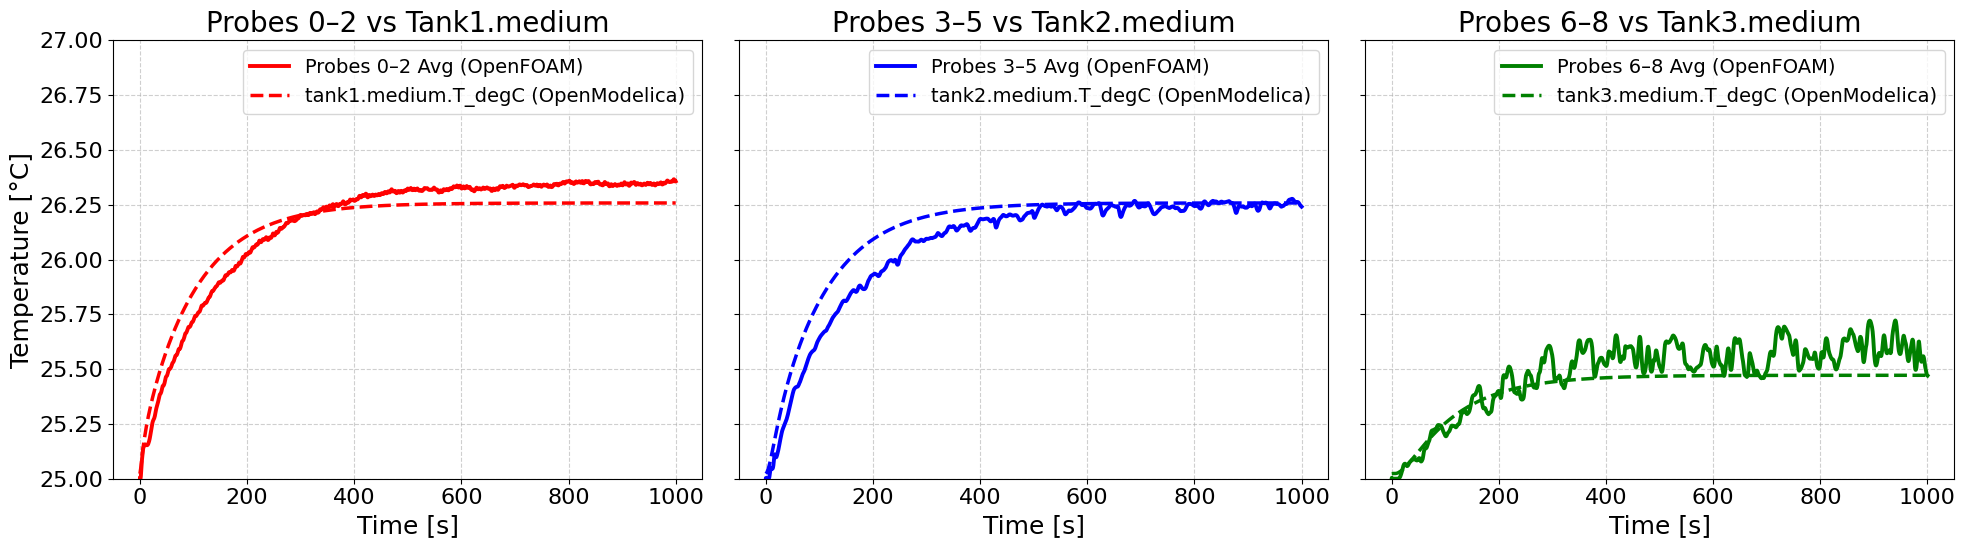

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re

# ====== OpenFOAM データ ======
base_dir = Path("postProcessing/probes")
quantity = "T"
smooth_window = 1

time_files = []
for p in base_dir.glob("*"):
    if p.is_dir() and re.fullmatch(r"\d+", p.name):
        f = p / quantity
        if f.is_file():
            time_files.append((int(p.name), f))
time_files.sort(key=lambda x: x[0])

frames = []
first_df = pd.read_csv(time_files[0][1], comment="#", delim_whitespace=True, header=None, engine="python")
ncols = first_df.shape[1]
for _, f in time_files:
    df_i = pd.read_csv(f, comment="#", delim_whitespace=True, header=None, engine="python")
    if df_i.shape[1] < ncols:
        for _ in range(ncols - df_i.shape[1]):
            df_i[df_i.shape[1]] = pd.NA
    elif df_i.shape[1] > ncols:
        df_i = df_i.iloc[:, :ncols]
    frames.append(df_i)

df_foam = pd.concat(frames, ignore_index=True)
df_foam.columns = ["Time"] + [f"Probe {i}" for i in range(df_foam.shape[1] - 1)]
df_foam = df_foam.sort_values("Time").drop_duplicates(subset="Time", keep="last").reset_index(drop=True)

# Kelvin → Celsius
for col in df_foam.columns[1:]:
    df_foam[col] = df_foam[col] - 273.15

# ==== 可視化のための間引き（OpenFOAMのみ）====
# 画面に出す点数の上限を target_points として、データ数に応じてステップを自動調整
target_points = 1000  # ここを好きな上限に（例: 1000〜5000）
step = max(len(df_foam) // target_points, 1)
df_foam_plot = df_foam.iloc[::step].copy()

# グループ平均（元データで計算 → プロット用に同様間引き）
group1 = df_foam[["Probe 0", "Probe 1", "Probe 2"]].mean(axis=1).iloc[::step].reset_index(drop=True)
group2 = df_foam[["Probe 3", "Probe 4", "Probe 5"]].mean(axis=1).iloc[::step].reset_index(drop=True)
group3 = df_foam[["Probe 6", "Probe 7", "Probe 8"]].mean(axis=1).iloc[::step].reset_index(drop=True)
time_plot = df_foam_plot["Time"].reset_index(drop=True)

# ====== OpenModelica データ ======
df_om = pd.read_csv(Path("./OM_csv/exportedVariables.csv"))

# ====== 描画設定 ======
plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 20,
    "legend.fontsize": 14,
})

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
colors = ["red", "blue", "green"]

# ---- 1列目（赤） ----
axes[0].plot(time_plot, group1, color=colors[0], linewidth=2.8, label="Probes 0–2 Avg (OpenFOAM)")
axes[0].plot(df_om["time"], df_om["tank.medium.T_degC"], color=colors[0], linestyle="--", linewidth=2.5, label="tank1.medium.T_degC (OpenModelica)")
axes[0].set_title("Probes 0–2 vs Tank1.medium")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Temperature [°C]")
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].set_ylim(25, 27)
axes[0].legend()

# ---- 2列目（青） ----
axes[1].plot(time_plot, group2, color=colors[1], linewidth=2.8, label="Probes 3–5 Avg (OpenFOAM)")
axes[1].plot(df_om["time"], df_om["tank1.medium.T_degC"], color=colors[1], linestyle="--", linewidth=2.5, label="tank2.medium.T_degC (OpenModelica)")
axes[1].set_title("Probes 3–5 vs Tank2.medium")
axes[1].set_xlabel("Time [s]")
axes[1].grid(True, linestyle="--", alpha=0.6)
axes[1].legend()
axes[1].set_ylim(25, 27)

# ---- 3列目（緑） ----
axes[2].plot(time_plot, group3, color=colors[2], linewidth=2.8, label="Probes 6–8 Avg (OpenFOAM)")
axes[2].plot(df_om["time"], df_om["tank11.medium.T_degC"], color=colors[2], linestyle="--", linewidth=2.5, label="tank3.medium.T_degC (OpenModelica)")
axes[2].set_title("Probes 6–8 vs Tank3.medium")
axes[2].set_xlabel("Time [s]")
axes[2].grid(True, linestyle="--", alpha=0.6)
axes[2].legend()
axes[2].set_ylim(25, 27)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()



C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\1349373748.py:22: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  first_df = pd.read_csv(time_files[0][1], comment="#", delim_whitespace=True, header=None, engine="python")
C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\1349373748.py:25: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_i = pd.read_csv(f, comment="#", delim_whitespace=True, header=None, engine="python")


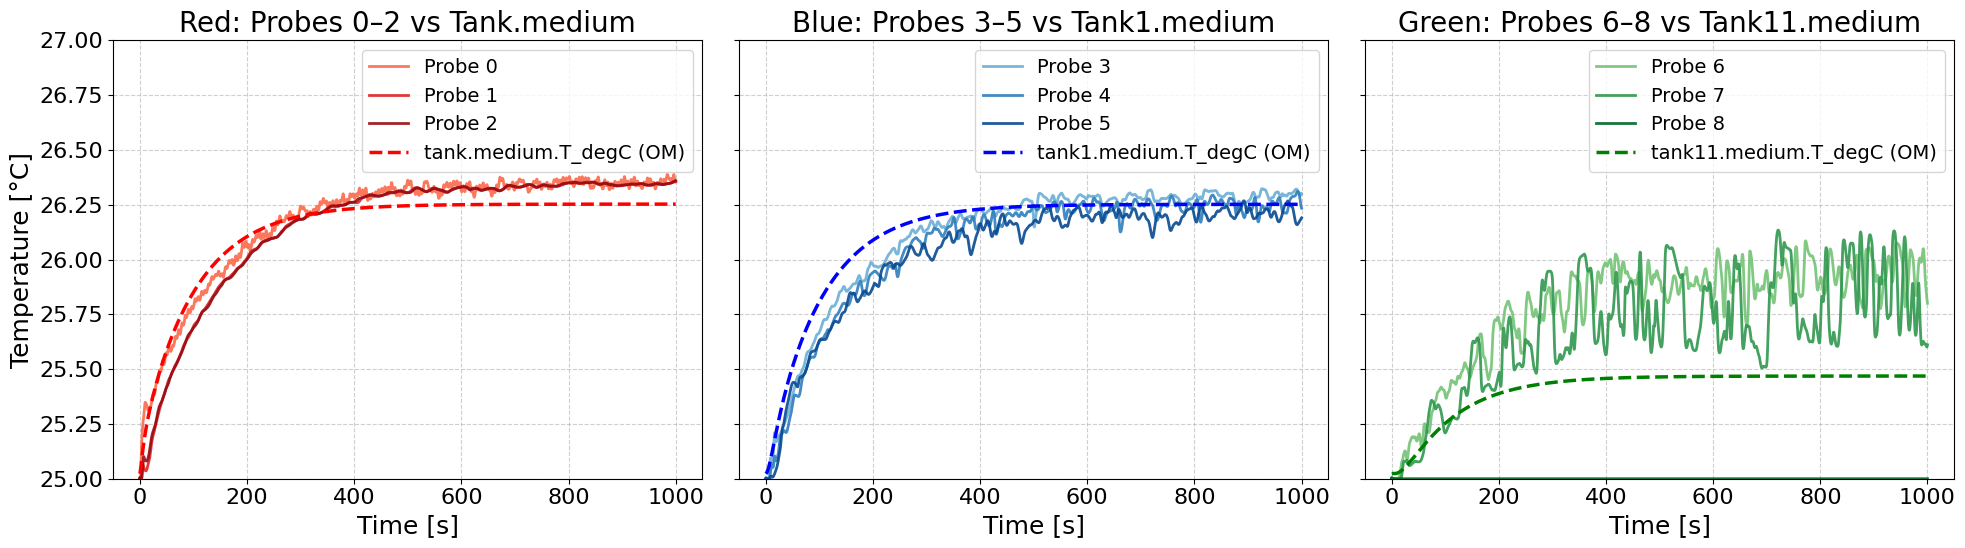

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re
import matplotlib.cm as cm
import numpy as np

# ====== OpenFOAM データ ======
base_dir = Path("postProcessing/probes_old")
quantity = "T"
smooth_window = 1

time_files = []
for p in base_dir.glob("*"):
    if p.is_dir() and re.fullmatch(r"\d+", p.name):
        f = p / quantity
        if f.is_file():
            time_files.append((int(p.name), f))
time_files.sort(key=lambda x: x[0])

frames = []
first_df = pd.read_csv(time_files[0][1], comment="#", delim_whitespace=True, header=None, engine="python")
ncols = first_df.shape[1]
for _, f in time_files:
    df_i = pd.read_csv(f, comment="#", delim_whitespace=True, header=None, engine="python")
    if df_i.shape[1] < ncols:
        for _ in range(ncols - df_i.shape[1]):
            df_i[df_i.shape[1]] = pd.NA
    elif df_i.shape[1] > ncols:
        df_i = df_i.iloc[:, :ncols]
    frames.append(df_i)
df_foam = pd.concat(frames, ignore_index=True)
df_foam.columns = ["Time"] + [f"Probe {i}" for i in range(df_foam.shape[1] - 1)]
df_foam = df_foam.sort_values("Time").drop_duplicates(subset="Time", keep="last").reset_index(drop=True)

# Kelvin → Celsius
for col in df_foam.columns[1:]:
    df_foam[col] = df_foam[col] - 273.15

# ====== OpenModelica データ ======
df_om = pd.read_csv(Path("./OM_csv/exportedVariables_3split.csv"))

# ====== 描画設定 ======
plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 20,
    "legend.fontsize": 14,
})

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# ====== カラーマップ設定 ======
reds = cm.Reds(np.linspace(0.5, 0.9, 3))
blues = cm.Blues(np.linspace(0.5, 0.9, 3))
greens = cm.Greens(np.linspace(0.5, 0.9, 3))

# ---- 1列目（Probes 0–2） ----
for i, c in zip(range(0, 3), reds):
    axes[0].plot(df_foam["Time"], df_foam[f"Probe {i}"], color=c, linewidth=2, alpha=0.9, label=f"Probe {i}")
axes[0].plot(df_om["time"], df_om["tank1.medium.T_degC"], color="red", linestyle="--", linewidth=2.5, label="tank.medium.T_degC (OM)")
axes[0].set_title("Red: Probes 0–2 vs Tank.medium")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Temperature [°C]")
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].set_ylim(25, 27)
axes[0].legend()

# ---- 2列目（Probes 3–5） ----
for i, c in zip(range(3, 6), blues):
    axes[1].plot(df_foam["Time"], df_foam[f"Probe {i}"], color=c, linewidth=2, alpha=0.9, label=f"Probe {i}")
axes[1].plot(df_om["time"], df_om["tank2.medium.T_degC"], color="blue", linestyle="--", linewidth=2.5, label="tank1.medium.T_degC (OM)")
axes[1].set_title("Blue: Probes 3–5 vs Tank1.medium")
axes[1].set_xlabel("Time [s]")
axes[1].grid(True, linestyle="--", alpha=0.6)
axes[1].legend()
axes[1].set_ylim(25, 27)

# ---- 3列目（Probes 6–8） ----
for i, c in zip(range(6, 9), greens):
    axes[2].plot(df_foam["Time"], df_foam[f"Probe {i}"], color=c, linewidth=2, alpha=0.9, label=f"Probe {i}")
axes[2].plot(df_om["time"], df_om["tank3.medium.T_degC"], color="green", linestyle="--", linewidth=2.5, label="tank11.medium.T_degC (OM)")
axes[2].set_title("Green: Probes 6–8 vs Tank11.medium")
axes[2].set_xlabel("Time [s]")
axes[2].grid(True, linestyle="--", alpha=0.6)
axes[2].legend()
axes[2].set_ylim(25, 27)

# ====== 全体レイアウト ======
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [28]:
# ===== 指標算出ユーティリティ =====
import numpy as np

def compute_final_value(y, tail_frac=0.1):
    """末尾 tail_frac(=後ろ10%) を平均して最終値の推定にする"""
    n = max(int(len(y) * tail_frac), 1)
    return float(np.nanmean(y[-n:]))

def compute_metrics(time, y, tol_abs=0.02, tol_rel=0.01):
    """
    ΔTmax と tsat を返す。
    - final は末尾平均
    - tol は max(abs, rel) ＝ ΔTmax の tol_rel(=1%) か tol_abs(=0.02°C) の大きい方
    - tsat は y が final - tol に初めて達した時刻（昇温想定）
    """
    y = np.asarray(y, dtype=float)
    t = np.asarray(time, dtype=float)

    # 初期・最終・上昇量
    y0 = float(y[0])
    yfin = compute_final_value(y, tail_frac=0.1)
    dTmax = yfin - y0

    # 許容幅（上昇がほぼゼロなら絶対値トルランスのみで判断）
    tol = max(tol_abs, abs(dTmax) * tol_rel)

    # 目標到達値（昇温前提。冷却なら符号で自動的に反転して機能）
    target = yfin - np.sign(dTmax) * tol

    # 到達時刻探索（最初に超えた/下回った点）
    if dTmax >= 0:
        hit = np.where(y >= target)[0]
    else:
        hit = np.where(y <= target)[0]

    tsat = float(t[hit[0]]) if len(hit) else np.nan
    return dTmax, tsat, y0, yfin, tol

def print_metrics(title, dTmax, tsat, y0, yfin, tol):
    print(f"[{title}]")
    print(f"  Initial T      : {y0:.3f} °C")
    print(f"  Final T (est.) : {yfin:.3f} °C  (tail-avg, tol={tol:.3f} °C)")
    print(f"  ΔTmax          : {dTmax:.3f} °C")
    print(f"  t_sat          : {('%.1f s' % tsat) if np.isfinite(tsat) else 'N/A'}")
    print("")

# ===== OpenFOAM 側（間引き後の描画データを使用したい場合は time_plot & group* を使う）=====
# 指標は“値”が重要なので、描画用に間引かない元の time と group を使ってもOKです。
# ここでは一貫性のため可視化に使った series（time_plot & group*）で計算します。

dT_g1, ts_g1, y0_g1, yf_g1, tol_g1 = compute_metrics(time_plot, group1)
dT_g2, ts_g2, y0_g2, yf_g2, tol_g2 = compute_metrics(time_plot, group2)
dT_g3, ts_g3, y0_g3, yf_g3, tol_g3 = compute_metrics(time_plot, group3)

print_metrics("OpenFOAM Group1 (Probes 0–2 avg)", dT_g1, ts_g1, y0_g1, yf_g1, tol_g1)
print_metrics("OpenFOAM Group2 (Probes 3–5 avg)", dT_g2, ts_g2, y0_g2, yf_g2, tol_g2)
print_metrics("OpenFOAM Group3 (Probes 6–8 avg)", dT_g3, ts_g3, y0_g3, yf_g3, tol_g3)

# ===== OpenModelica 側 =====
# 列名に合わせて参照（ご提示の凡例に合わせて tank1, tank2, tank3 と解釈）
om_t = df_om["time"].to_numpy()

om1 = df_om["tank1.medium.T_degC"].to_numpy()     # tank1
om2 = df_om["tank2.medium.T_degC"].to_numpy()    # tank2
om3 = df_om["tank3.medium.T_degC"].to_numpy()   # tank3

dT_o1, ts_o1, y0_o1, yf_o1, tol_o1 = compute_metrics(om_t, om1)
dT_o2, ts_o2, y0_o2, yf_o2, tol_o2 = compute_metrics(om_t, om2)
dT_o3, ts_o3, y0_o3, yf_o3, tol_o3 = compute_metrics(om_t, om3)

print_metrics("OpenModelica Tank1", dT_o1, ts_o1, y0_o1, yf_o1, tol_o1)
print_metrics("OpenModelica Tank2", dT_o2, ts_o2, y0_o2, yf_o2, tol_o2)
print_metrics("OpenModelica Tank3", dT_o3, ts_o3, y0_o3, yf_o3, tol_o3)


[OpenFOAM Group1 (Probes 0–2 avg)]
  Initial T      : 25.000 °C
  Final T (est.) : 26.347 °C  (tail-avg, tol=0.020 °C)
  ΔTmax          : 1.347 °C
  t_sat          : 548.9 s

[OpenFOAM Group2 (Probes 3–5 avg)]
  Initial T      : 25.000 °C
  Final T (est.) : 26.252 °C  (tail-avg, tol=0.020 °C)
  ΔTmax          : 1.252 °C
  t_sat          : 509.4 s

[OpenFOAM Group3 (Probes 6–8 avg)]
  Initial T      : 25.000 °C
  Final T (est.) : 25.586 °C  (tail-avg, tol=0.020 °C)
  ΔTmax          : 0.586 °C
  t_sat          : 287.0 s

[OpenModelica Tank1]
  Initial T      : 25.023 °C
  Final T (est.) : 26.253 °C  (tail-avg, tol=0.020 °C)
  ΔTmax          : 1.230 °C
  t_sat          : 402.0 s

[OpenModelica Tank2]
  Initial T      : 25.023 °C
  Final T (est.) : 26.252 °C  (tail-avg, tol=0.020 °C)
  ΔTmax          : 1.229 °C
  t_sat          : 412.0 s

[OpenModelica Tank3]
  Initial T      : 25.023 °C
  Final T (est.) : 25.468 °C  (tail-avg, tol=0.020 °C)
  ΔTmax          : 0.446 °C
  t_sat          : 3

In [20]:
print_metrics("OpenModelica Tank2", dT_o2, ts_o2, y0_o2, yf_o2, tol_o2)

[OpenModelica Tank2]
  Initial T      : 25.023 °C
  Final T (est.) : 26.258 °C  (tail-avg, tol=0.020 °C)
  ΔTmax          : 1.235 °C
  t_sat          : 414.0 s



In [21]:
print_metrics("OpenModelica Tank1", dT_o1, ts_o1, y0_o1, yf_o1, tol_o1)

[OpenModelica Tank1]
  Initial T      : 25.023 °C
  Final T (est.) : 26.258 °C  (tail-avg, tol=0.020 °C)
  ΔTmax          : 1.235 °C
  t_sat          : 404.0 s



In [22]:
print_metrics("OpenModelica Tank3", dT_o3, ts_o3, y0_o3, yf_o3, tol_o3)


[OpenModelica Tank3]
  Initial T      : 25.023 °C
  Final T (est.) : 25.472 °C  (tail-avg, tol=0.020 °C)
  ΔTmax          : 0.449 °C
  t_sat          : 342.0 s



# 領域分割（6分割）

対象ディレクトリ：
  - volFieldValue6_1
  - volFieldValue6_2
  - volFieldValue6_3
  - volFieldValue6_4
  - volFieldValue6_5
  - volFieldValue6_6


C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\4157172159.py:34: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(dat_file, delim_whitespace=True, comment="#", header=None)
C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\4157172159.py:34: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(dat_file, delim_whitespace=True, comment="#", header=None)
C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\4157172159.py:34: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(dat_file, delim_whitespace=True, comment="#", header=None)
C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\4157172159.py:34: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is depr

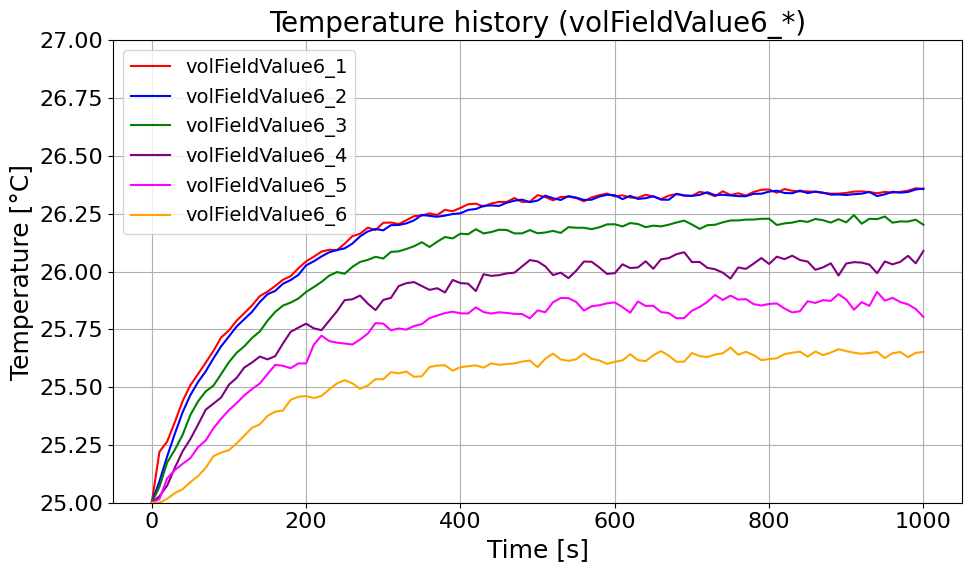

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ========= パス =========
root = Path("./postProcessing")

# ========= volFieldValue6_* を自動探索 =========
dirs = sorted([d for d in root.glob("volFieldValue6_*") if d.is_dir()])

print("対象ディレクトリ：")
for d in dirs:
    print("  -", d.name)

plt.figure(figsize=(10,6))

# ========= tank1〜tank6 と同じ色を定義 =========
colors = [
    "#ff0000",  # tank1 赤
    "#0000ff",  # tank2 青
    "#008000",  # tank3 緑
    "#800080",  # tank4 紫
    "#ff00ff",  # tank5 マゼンタ
    "#ffa500",  # tank6 オレンジ
]

# ========= データ読み込み & プロット =========
for i, d in enumerate(dirs):
    dat_file = d / "1000/volFieldValue.dat"
    if not dat_file.exists():
        print(f"  → {dat_file} が無いためスキップ")
        continue

    df = pd.read_csv(dat_file, delim_whitespace=True, comment="#", header=None)
    df.columns = ["time", "T"]

    # Kelvin → °C
    df["T_C"] = df["T"] - 273.15

    # 色を指定してプロット
    plt.plot(df["time"], df["T_C"], label=d.name, color=colors[i % len(colors)])

# ========= グラフ設定 =========
plt.xlabel("Time [s]")
plt.ylabel("Temperature [°C]")
plt.title("Temperature history (volFieldValue6_*)")
plt.legend()
plt.grid(True)

plt.ylim(25, 27)
plt.yticks([25 + 0.25*i for i in range(int((27-25)/0.25) + 1)])

plt.tight_layout()
plt.show()


対象ディレクトリ（OpenFOAM）：
  - volFieldValue6_1
  - volFieldValue6_2
  - volFieldValue6_3
  - volFieldValue6_4
  - volFieldValue6_5
  - volFieldValue6_6


C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\1048618538.py:35: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(dat_file, delim_whitespace=True, comment="#", header=None)
C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\1048618538.py:35: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(dat_file, delim_whitespace=True, comment="#", header=None)
C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\1048618538.py:35: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(dat_file, delim_whitespace=True, comment="#", header=None)
C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\1048618538.py:35: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is depr

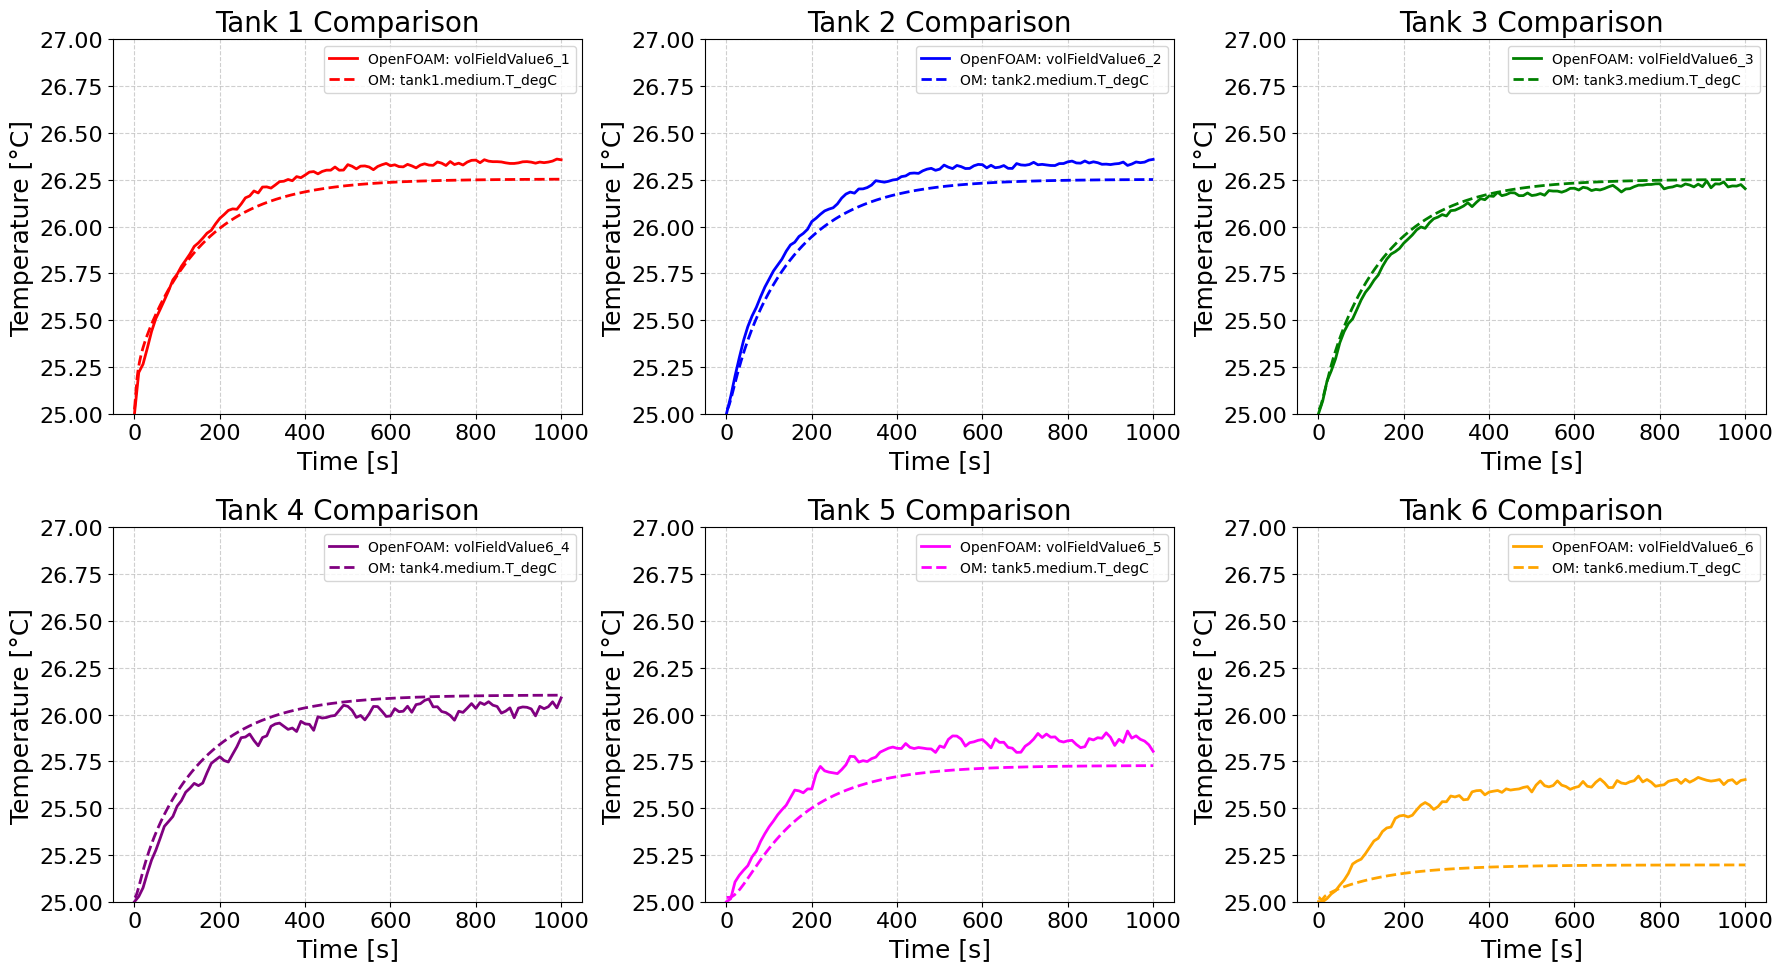

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================
# OpenFOAM データ読み込み
# =========================================

root = Path("./postProcessing")

dirs = sorted([d for d in root.glob("volFieldValue6_*") if d.is_dir()])

print("対象ディレクトリ（OpenFOAM）：")
for d in dirs:
    print("  -", d.name)

# tank と対応付けるために 6 本まで使用
colors = [
    "#ff0000",  # tank1 赤
    "#0000ff",  # tank2 青
    "#008000",  # tank3 緑
    "#800080",  # tank4 紫
    "#ff00ff",  # tank5 マゼンタ
    "#ffa500",  # tank6 オレンジ
]

foam_curves = []
foam_time = None

for i, d in enumerate(dirs):
    dat_file = d / "1000/volFieldValue.dat"
    if not dat_file.exists():
        continue

    df = pd.read_csv(dat_file, delim_whitespace=True, comment="#", header=None)
    df.columns = ["time", "T"]
    df["T_C"] = df["T"] - 273.15  # Kelvin → ℃

    foam_curves.append(df["T_C"])
    foam_time = df["time"]  # 同じである前提


# =========================================
# OpenModelica データ
# =========================================

df_om = pd.read_csv("./OM_csv/exportedVariables_6split.csv")

# tank1〜6 を対応させる
om_cols = [
    "tank1.medium.T_degC",
    "tank2.medium.T_degC",
    "tank3.medium.T_degC",
    "tank4.medium.T_degC",
    "tank5.medium.T_degC",
    "tank6.medium.T_degC",
]


# =========================================
# プロット（6 枚の比較図）
# =========================================

plt.figure(figsize=(18, 10))

for i in range(6):
    ax = plt.subplot(2, 3, i+1)

    # OpenFOAM
    ax.plot(foam_time, foam_curves[i], color=colors[i], linewidth=2.0,
            label=f"OpenFOAM: volFieldValue6_{i+1}")

    # OpenModelica
    ax.plot(df_om["time"], df_om[om_cols[i]], color=colors[i],
            linestyle="--", linewidth=2.0,
            label=f"OM: {om_cols[i]}")

    ax.set_title(f"Tank {i+1} Comparison")
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Temperature [°C]")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_ylim(25, 27)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


対象ディレクトリ（OpenFOAM）：
  - volFieldValue6_1
  - volFieldValue6_2
  - volFieldValue6_3
  - volFieldValue6_4
  - volFieldValue6_5
  - volFieldValue6_6


C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\3830532034.py:36: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(dat_file, delim_whitespace=True, comment="#", header=None)
C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\3830532034.py:36: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(dat_file, delim_whitespace=True, comment="#", header=None)
C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\3830532034.py:36: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(dat_file, delim_whitespace=True, comment="#", header=None)
C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\3830532034.py:36: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is depr

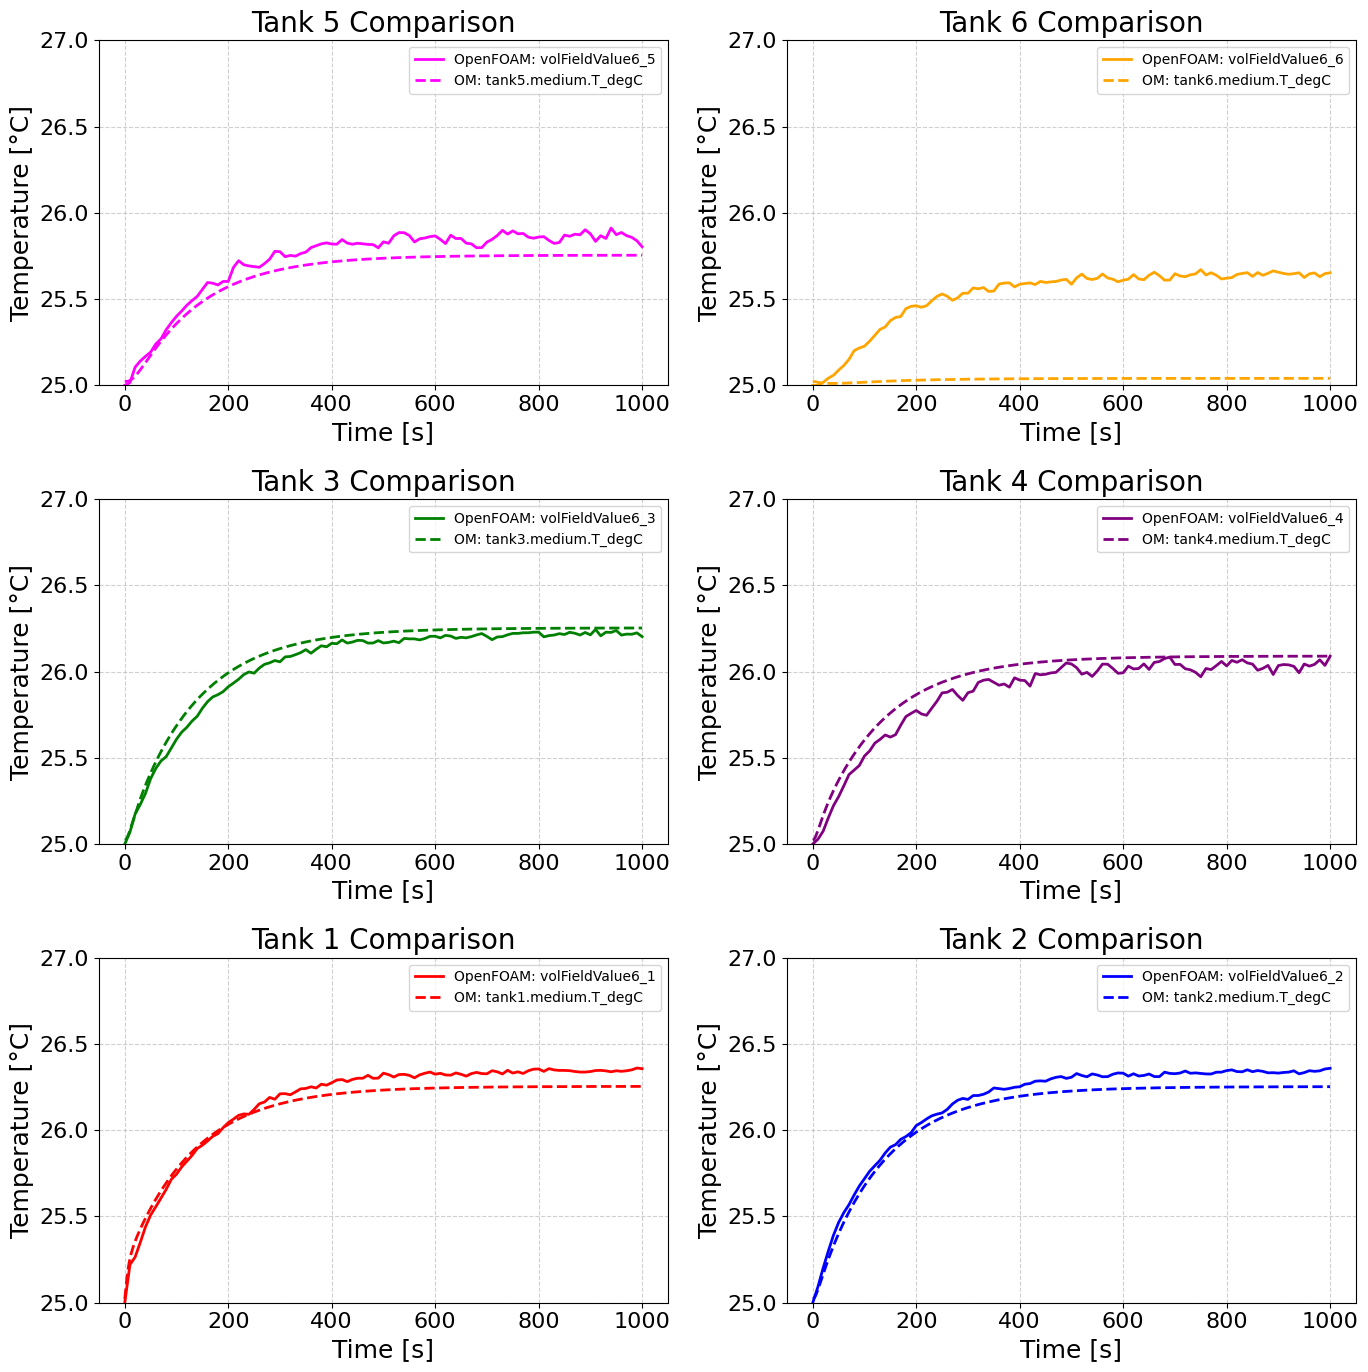

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================
# OpenFOAM データ読み込み
# =========================================

root = Path("./postProcessing")

dirs = sorted([d for d in root.glob("volFieldValue6_*") if d.is_dir()])

print("対象ディレクトリ（OpenFOAM）：")
for d in dirs:
    print("  -", d.name)

# 色（tank1〜6）
colors = [
    "#ff0000",  # tank1 赤
    "#0000ff",  # tank2 青
    "#008000",  # tank3 緑
    "#800080",  # tank4 紫
    "#ff00ff",  # tank5 マゼンタ
    "#ffa500",  # tank6 オレンジ
]

foam_curves = []
foam_time = None

# volFieldValue6_1,2,... の順で入る想定
for i, d in enumerate(dirs):
    dat_file = d / "1000/volFieldValue.dat"
    if not dat_file.exists():
        continue

    df = pd.read_csv(dat_file, delim_whitespace=True, comment="#", header=None)
    df.columns = ["time", "T"]
    df["T_C"] = df["T"] - 273.15  # Kelvin → ℃

    foam_curves.append(df["T_C"])
    foam_time = df["time"]  # 同じである前提


# =========================================
# OpenModelica データ
# =========================================

df_om = pd.read_csv("./OM_csv/exportedVariables_6split.csv")

om_cols = [
    "tank1.medium.T_degC",
    "tank2.medium.T_degC",
    "tank3.medium.T_degC",
    "tank4.medium.T_degC",
    "tank5.medium.T_degC",
    "tank6.medium.T_degC",
]

# =========================================
# ★ 並び順変更
# 指定：上から [5,6], [3,4], [1,2]
# tank番号 → インデックスに変換
# tank5 → index 4, tank6 → index 5 ...
# =========================================
order = [4, 5, 2, 3, 0, 1]   # 0-based index

# =========================================
# プロット
# =========================================

plt.figure(figsize=(14, 14))

for plot_idx, tank_idx in enumerate(order):
    ax = plt.subplot(3, 2, plot_idx + 1)

    # ---- OpenFOAM ----
    ax.plot(
        foam_time,
        foam_curves[tank_idx],
        color=colors[tank_idx],
        linewidth=2.0,
        label=f"OpenFOAM: volFieldValue6_{tank_idx+1}"
    )

    # ---- OpenModelica ----
    ax.plot(
        df_om["time"],
        df_om[om_cols[tank_idx]],
        color=colors[tank_idx],
        linestyle="--",
        linewidth=2.0,
        label=f"OM: {om_cols[tank_idx]}"
    )

    ax.set_title(f"Tank {tank_idx + 1} Comparison")
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Temperature [°C]")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_ylim(25, 27)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


=== OpenFOAM 読み込み ===
 - volFieldValue6_1
 - volFieldValue6_2
 - volFieldValue6_3
 - volFieldValue6_4
 - volFieldValue6_5
 - volFieldValue6_6

ρCpV = 50400.0
（1 tank あたりの ρCpV × T[K] が熱量[J]）



C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\1551202049.py:23: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(dat_file, delim_whitespace=True, comment="#", header=None)
C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\1551202049.py:23: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(dat_file, delim_whitespace=True, comment="#", header=None)
C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\1551202049.py:23: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(dat_file, delim_whitespace=True, comment="#", header=None)
C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\1551202049.py:23: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is depr

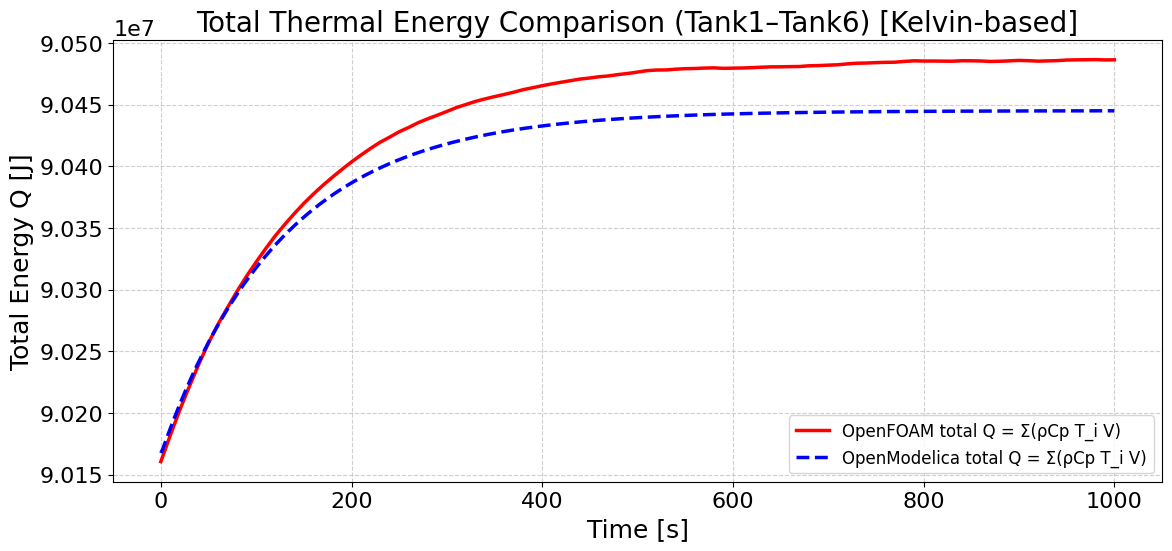


===== 最終時刻の熱量 Q(t_last) =====
OpenFOAM Q_last = 9.049e+07 [J]
OpenModelica Q_last = 9.044e+07 [J]
差 ≈ 4.133e+04 [J]


In [65]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================
# 1) OpenFOAM データ読み込み
# =========================================

root = Path("./postProcessing")
dirs = sorted([d for d in root.glob("volFieldValue6_*") if d.is_dir()])

foam_curves = []
foam_time = None

print("=== OpenFOAM 読み込み ===")
for d in dirs:
    print(" -", d.name)
    dat_file = d / "1000/volFieldValue.dat"
    if not dat_file.exists():
        print("   → ファイルなし、スキップ")
        continue

    df = pd.read_csv(dat_file, delim_whitespace=True, comment="#", header=None)
    df.columns = ["time", "T_K"]      # Kelvin のまま使用
    foam_curves.append(df["T_K"])
    foam_time = df["time"]            # 全 tank 共通の時間軸と仮定


# =========================================
# 2) OpenModelica データ読み込み
# =========================================

df_om = pd.read_csv("./OM_csv/exportedVariables_6split.csv")

# tank1〜tank6 の温度列（℃ → K に変換）
om_cols_degC = [
    "tank1.medium.T_degC",
    "tank2.medium.T_degC",
    "tank3.medium.T_degC",
    "tank4.medium.T_degC",
    "tank5.medium.T_degC",
    "tank6.medium.T_degC",
]

om_cols_K = [c.replace("_degC", "_K") for c in om_cols_degC]

for colC, colK in zip(om_cols_degC, om_cols_K):
    df_om[colK] = df_om[colC] + 273.15     # Kelvin に変換


# =========================================
# 3) ρCpV の定義
# =========================================

rho = 1000           # [kg/m3]
Cp  = 4200           # [J/kgK]
V   = 0.25 * 0.30 * 0.16    # [m3] (= 0.075 m³)

rhoCpV = rho * Cp * V

print("\nρCpV =", rhoCpV)
print("（1 tank あたりの ρCpV × T[K] が熱量[J]）\n")


# =========================================
# 4) 総熱量 Q_total(t) = Σ ρCpV * Ti(t) を計算
# =========================================

# ---- OpenFOAM ----
FOAM_Q_total = foam_curves[0] * rhoCpV
for i in range(1, len(foam_curves)):
    FOAM_Q_total += foam_curves[i] * rhoCpV

# ---- OpenModelica ----
OM_Q_total = df_om[om_cols_K[0]] * rhoCpV
for i in range(1, 6):
    OM_Q_total += df_om[om_cols_K[i]] * rhoCpV


# =========================================
# 5) プロット：総熱量の比較
# =========================================

plt.figure(figsize=(12, 6))

plt.plot(
    foam_time,
    FOAM_Q_total,
    color="red",
    linewidth=2.5,
    label="OpenFOAM total Q = Σ(ρCp T_i V)"
)

plt.plot(
    df_om["time"],
    OM_Q_total,
    color="blue",
    linestyle="--",
    linewidth=2.5,
    label="OpenModelica total Q = Σ(ρCp T_i V)"
)

plt.title("Total Thermal Energy Comparison (Tank1–Tank6) [Kelvin-based]")
plt.xlabel("Time [s]")
plt.ylabel("Total Energy Q [J]")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()


# =========================================
# 7) 最終時刻の総熱量の大きさ（縦軸の参考値）
# =========================================

# OpenFOAM の最終時刻 Q
FOAM_Q_last = FOAM_Q_total.iloc[-1]

# OM の最終時刻 Q
OM_Q_last = OM_Q_total.iloc[-1]

print("\n===== 最終時刻の熱量 Q(t_last) =====")
print(f"OpenFOAM Q_last = {FOAM_Q_last:.3e} [J]")
print(f"OpenModelica Q_last = {OM_Q_last:.3e} [J]")

# y 軸の最大候補
ymax_suggest = max(FOAM_Q_last, OM_Q_last)
print(f"差 ≈ {FOAM_Q_last - OM_Q_last:.3e} [J]")


# 領域分割（3分割）

対象ディレクトリ：
  - volFieldValue3_1
  - volFieldValue3_2
  - volFieldValue3_3


C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\3945868586.py:34: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(dat_file, delim_whitespace=True, comment="#", header=None)
C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\3945868586.py:34: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(dat_file, delim_whitespace=True, comment="#", header=None)
C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\3945868586.py:34: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(dat_file, delim_whitespace=True, comment="#", header=None)


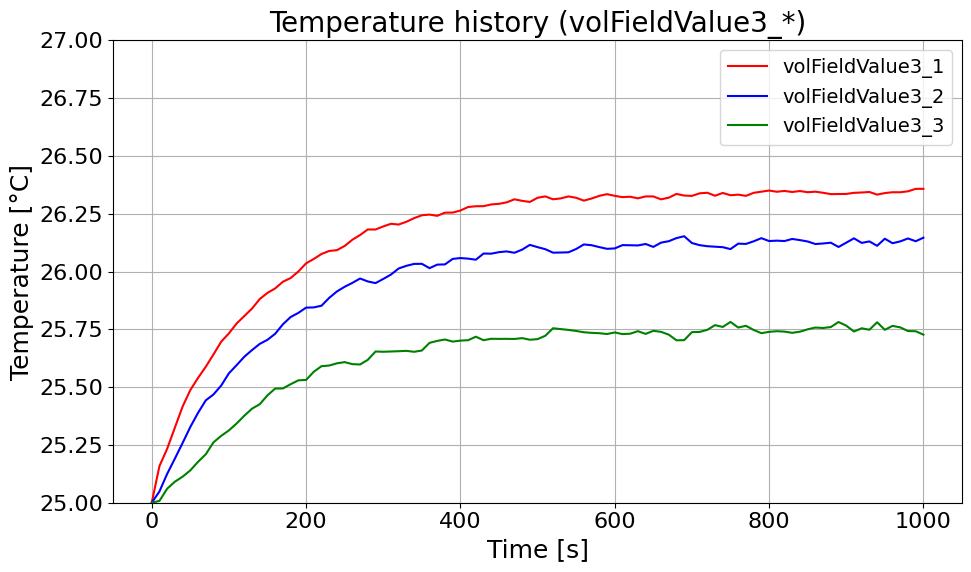

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ========= パス =========
root = Path("./postProcessing")

# ========= volFieldValue3_* を自動探索 =========
dirs = sorted([d for d in root.glob("volFieldValue3_*") if d.is_dir()])

print("対象ディレクトリ：")
for d in dirs:
    print("  -", d.name)

plt.figure(figsize=(10,6))

# ========= tank と同じ色（必要なら短縮） =========
colors = [
    "#ff0000",  # 赤
    "#0000ff",  # 青
    "#008000",  # 緑
    "#800080",  # 紫
    "#ff00ff",  # マゼンタ
    "#ffa500",  # オレンジ
]

# ========= データ読み込み & プロット =========
for i, d in enumerate(dirs):
    dat_file = d / "1000" / "volFieldValue.dat"
    if not dat_file.exists():
        print(f"  → {dat_file} が無いためスキップ")
        continue

    df = pd.read_csv(dat_file, delim_whitespace=True, comment="#", header=None)
    df.columns = ["time", "T"]

    # Kelvin → °C
    df["T_C"] = df["T"] - 273.15

    # 色を指定してプロット
    plt.plot(df["time"], df["T_C"], label=d.name, color=colors[i % len(colors)])

# ========= グラフ設定 =========
plt.xlabel("Time [s]")
plt.ylabel("Temperature [°C]")
plt.title("Temperature history (volFieldValue3_*)")  # ← 修正ポイント
plt.legend()
plt.grid(True)

plt.ylim(25, 27)
plt.yticks([25 + 0.25*i for i in range(int((27 - 25) / 0.25) + 1)])

plt.tight_layout()
plt.show()


対象ディレクトリ（OpenFOAM 3_*）：
  - volFieldValue3_1
  - volFieldValue3_2
  - volFieldValue3_3

   最終時間の温度一覧

OpenFOAM 最終時間 = 1000 [s]

  FOAM tank1:  T = 26.3576 °C, deltaT = 1.3576 °C
  FOAM tank2:  T = 26.1464 °C, deltaT = 1.1464 °C
  FOAM tank3:  T = 25.7270 °C, deltaT = 0.7270 °C

OpenModelica 最終時間 = 1000 [s]

  OM tank1:   T = 26.2528 °C, deltaT = 1.2528 °C
  OM tank2:   T = 26.2518 °C, deltaT = 1.2518 °C
  OM tank3:   T = 25.4685 °C, deltaT = 0.4685 °C


C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\3129866054.py:28: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(dat_file, delim_whitespace=True, comment="#", header=None)
C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\3129866054.py:28: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(dat_file, delim_whitespace=True, comment="#", header=None)
C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\3129866054.py:28: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(dat_file, delim_whitespace=True, comment="#", header=None)


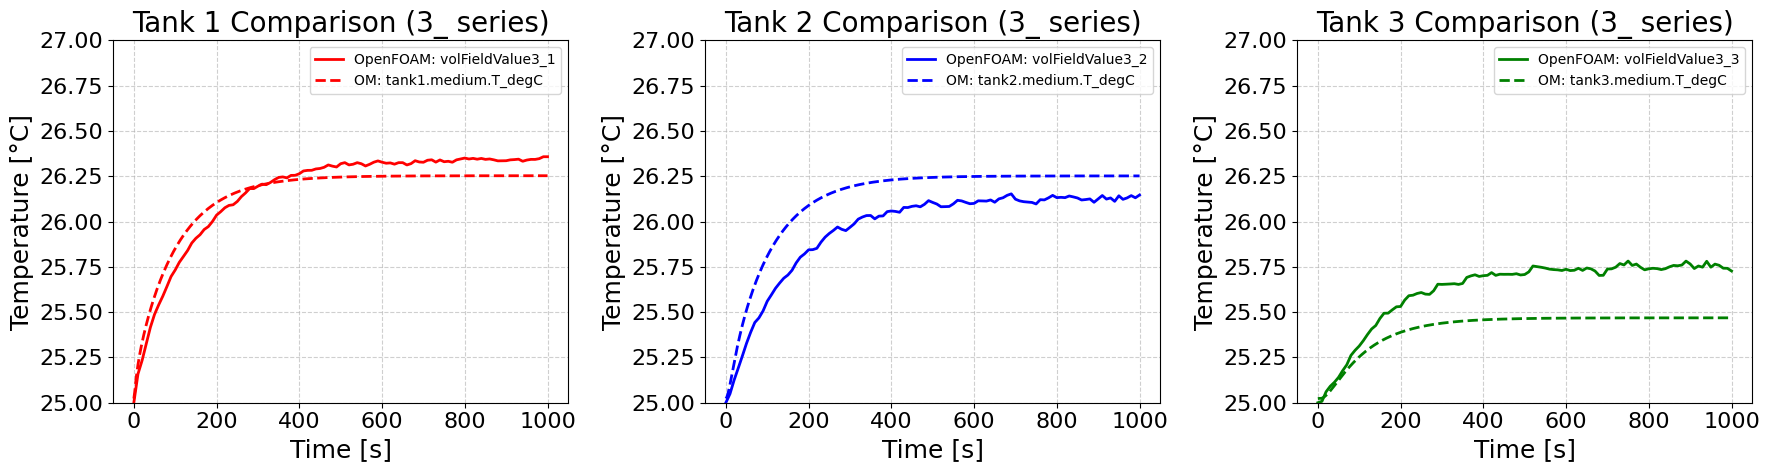

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================
# OpenFOAM データ読み込み（3 系）
# =========================================

root = Path("./postProcessing")

dirs = sorted([d for d in root.glob("volFieldValue3_*") if d.is_dir()])

print("対象ディレクトリ（OpenFOAM 3_*）：")
for d in dirs:
    print("  -", d.name)

colors = ["#ff0000", "#0000ff", "#008000"]  # 3本の色

foam_curves = []
foam_time = None

for i, d in enumerate(dirs):
    dat_file = d / "1000/volFieldValue.dat"
    if not dat_file.exists():
        print("Missing:", dat_file)
        continue

    df = pd.read_csv(dat_file, delim_whitespace=True, comment="#", header=None)
    df.columns = ["time", "T"]
    df["T_C"] = df["T"] - 273.15  # Kelvin → ℃

    foam_curves.append(df["T_C"])
    foam_time = df["time"]


# =========================================
# OpenModelica データ
# =========================================

df_om = pd.read_csv("./OM_csv/exportedVariables_3split.csv")

om_cols = [
    "tank1.medium.T_degC",
    "tank2.medium.T_degC",
    "tank3.medium.T_degC",
]


# =========================================
# ★ 最終時間の温度を計算
# =========================================

print("\n==============================")
print("   最終時間の温度一覧")
print("==============================\n")

# --- OpenFOAM ---
foam_last_time = foam_time.max()
print(f"OpenFOAM 最終時間 = {foam_last_time} [s]\n")

for i in range(3):
    temp_final = foam_curves[i].iloc[-1]
    print(f"  FOAM tank{i+1}:  T = {temp_final:.4f} °C, deltaT = {temp_final - 25:.4f} °C")

# --- OpenModelica ---
om_last_time = df_om["time"].max()
print(f"\nOpenModelica 最終時間 = {om_last_time} [s]\n")

for i in range(3):
    # 最終時間における行を取得
    row = df_om.loc[df_om["time"] == om_last_time, om_cols[i]]
    if not row.empty:
        print(f"  OM tank{i+1}:   T = {row.values[0]:.4f} °C, deltaT = {row.values[0] - 25:.4f} °C")
    else:
        print(f"  OM tank{i+1}:   （最終時刻の値が見つかりません）")


# =========================================
# プロット（3 枚）
# =========================================

plt.figure(figsize=(18, 5))

for i in range(3):
    ax = plt.subplot(1, 3, i+1)

    # OpenFOAM
    ax.plot(
        foam_time,
        foam_curves[i],
        color=colors[i],
        linewidth=2.0,
        label=f"OpenFOAM: volFieldValue3_{i+1}")

    # OpenModelica
    ax.plot(
        df_om["time"],
        df_om[om_cols[i]],
        color=colors[i],
        linestyle="--",
        linewidth=2.0,
        label=f"OM: {om_cols[i]}")

    ax.set_title(f"Tank {i+1} Comparison (3_ series)")
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Temperature [°C]")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_ylim(25, 27)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


# 流入流出温度

対象ディレクトリ：
  - surfaceFieldValue_floodOutlet_press_2-4_0
  - surfaceFieldValue_mainInlet_vol_2-4_0
  - surfaceFieldValue_pumpOutlet_vol_2-4_0
  - surfaceFieldValue_tempInlet_vol_3-6_0
  - surfaceFieldValue_tempOutlet_vol_3-6_0


C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\1760219636.py:27: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(dat_file, comment="#", delim_whitespace=True, header=None)
C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\1760219636.py:27: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(dat_file, comment="#", delim_whitespace=True, header=None)
C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\1760219636.py:27: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(dat_file, comment="#", delim_whitespace=True, header=None)
C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\1760219636.py:27: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is depr

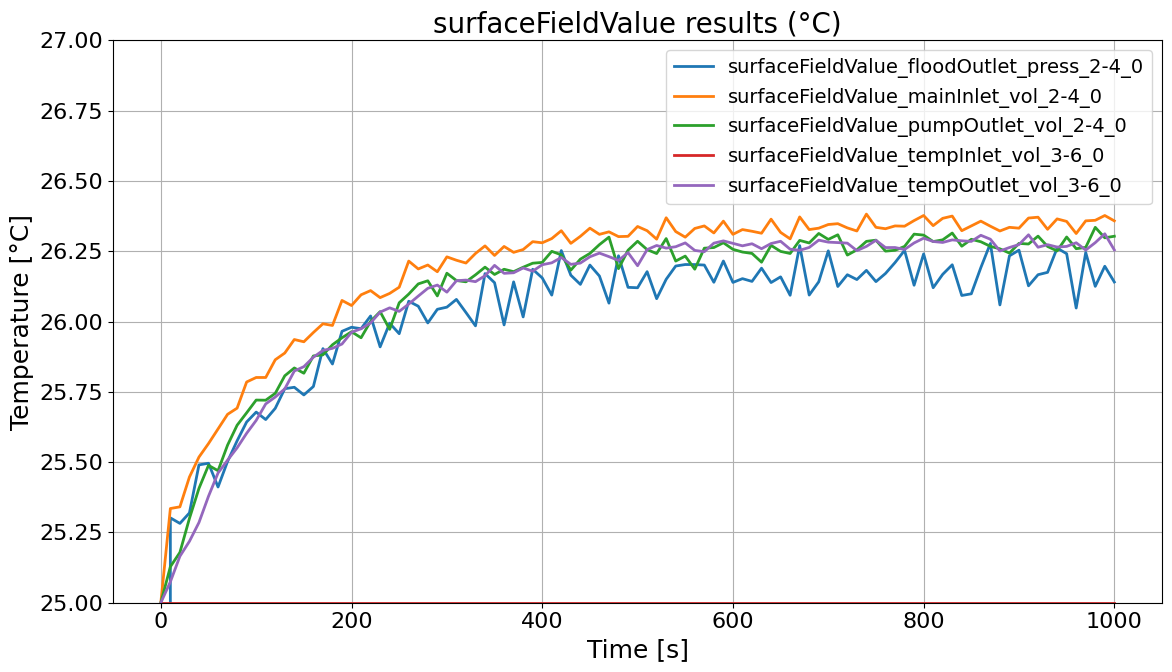

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ========= パス =========
root = Path("./postProcessing")

# ========= surfaceFieldValue_* ディレクトリを探索 =========
dirs = sorted(root.glob("surfaceFieldValue_*"))

print("対象ディレクトリ：")
for d in dirs:
    print("  -", d.name)

plt.figure(figsize=(12, 7))

colors = plt.cm.tab10.colors

# ========= データ読み込み & プロット =========
for i, d in enumerate(dirs):
    dat_file = d / "1000" / "surfaceFieldValue.dat"
    if not dat_file.exists():
        print(f"  → {dat_file} が無いためスキップ")
        continue

    # 読み込み
    df = pd.read_csv(dat_file, comment="#", delim_whitespace=True, header=None)
    df.columns = ["time", "T"]

    # ----★ Kelvin → Celsius 変換 ----
    df["T_C"] = df["T"] - 273.15

    # プロット
    plt.plot(df["time"], df["T_C"], label=d.name, 
             color=colors[i % len(colors)], linewidth=2)

# ========= グラフ設定 =========
plt.xlabel("Time [s]")
plt.ylabel("Temperature [°C]")
plt.title("surfaceFieldValue results (°C)")
plt.grid(True)

# ----★ 縦軸 25〜27℃、0.25刻み ----
plt.ylim(25, 27)
plt.yticks([25 + 0.25*i for i in range(int((27 - 25) / 0.25) + 1)])

plt.legend()
plt.tight_layout()
plt.show()


比較対象（OpenFOAM）：surfaceFieldValue_floodOutlet_press_2-4_0


C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\804498793.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_foam = pd.read_csv(foam_file, comment="#", delim_whitespace=True, header=None)


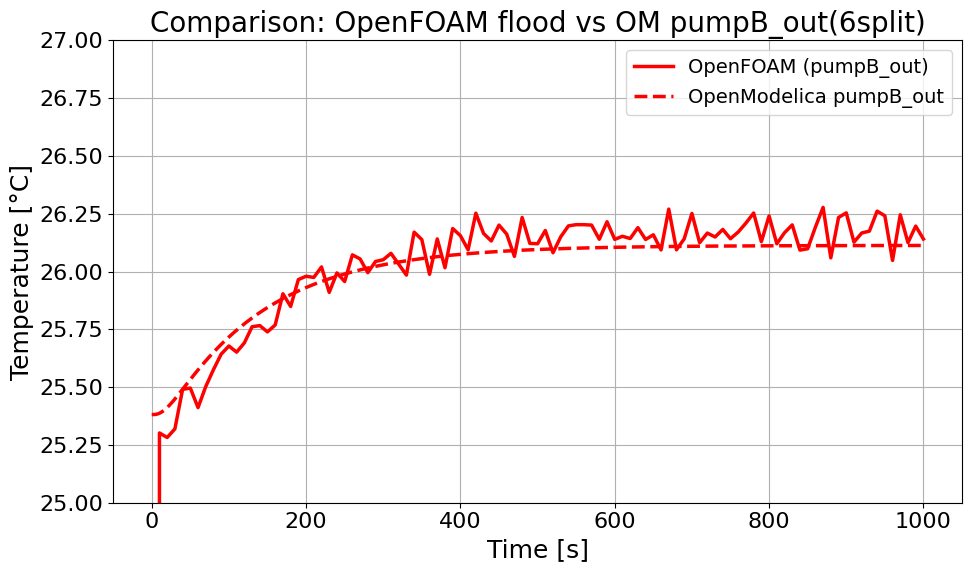

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

root = Path("./postProcessing")
om_csv = Path("./OM_csv/exportedVariables_6split.csv")

# ===== OpenFOAM（flood）を探す =====
dirs = sorted(root.glob("surfaceFieldValue_*"))
target_dir = next((d for d in dirs if "flood" in d.name.lower()), None)

if target_dir is None:
    raise ValueError("flood の surfaceFieldValue_* が見つかりませんでした！")

print(f"比較対象（OpenFOAM）：{target_dir.name}")

# ===== OpenFOAM 読み込み =====
foam_file = target_dir / "1000" / "surfaceFieldValue.dat"
df_foam = pd.read_csv(foam_file, comment="#", delim_whitespace=True, header=None)
df_foam.columns = ["time", "T"]
df_foam["T_C"] = df_foam["T"] - 273.15

# ===== OM 読み込み =====
df_om = pd.read_csv(om_csv)

col_om = "T_pumpB_out.T"
if col_om not in df_om.columns:
    raise ValueError(f"CSVに {col_om} がありません。列名を確認してください。")

# ===== Plot =====
plt.figure(figsize=(10, 6))

plt.plot(df_foam["time"], df_foam["T_C"], label="OpenFOAM (pumpB_out)",
         color="red", linewidth=2.5)

plt.plot(df_om["time"], df_om[col_om], label="OpenModelica pumpB_out",
         color="red", linestyle="--", linewidth=2.5)

plt.xlabel("Time [s]")
plt.ylabel("Temperature [°C]")
plt.title("Comparison: OpenFOAM flood vs OM pumpB_out(6split)")
plt.grid(True)

plt.ylim(25, 27)
plt.yticks([25 + 0.25*i for i in range(int((27-25)/0.25) + 1)])

plt.legend()
plt.tight_layout()
plt.show()


比較対象（OpenFOAM）：surfaceFieldValue_floodOutlet_press_2-4_0


C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\238849755.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_foam = pd.read_csv(foam_file, comment="#", delim_whitespace=True, header=None)


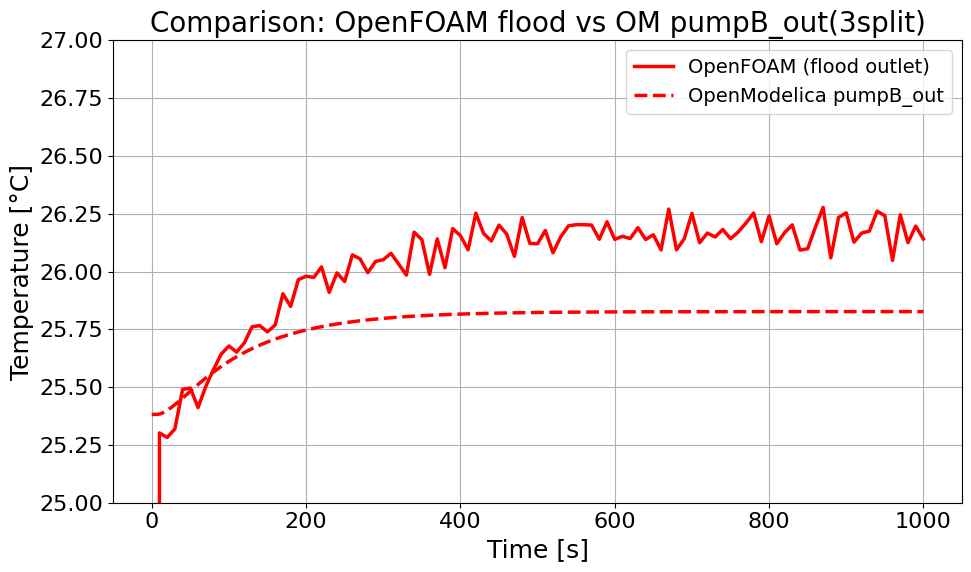

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

root = Path("./postProcessing")
om_csv = Path("./OM_csv/exportedVariables_3split.csv")

# ===== OpenFOAM（flood）を探す =====
dirs = sorted(root.glob("surfaceFieldValue_*"))
target_dir = next((d for d in dirs if "flood" in d.name.lower()), None)

if target_dir is None:
    raise ValueError("flood の surfaceFieldValue_* が見つかりませんでした！")

print(f"比較対象（OpenFOAM）：{target_dir.name}")

# ===== OpenFOAM 読み込み =====
foam_file = target_dir / "1000" / "surfaceFieldValue.dat"
df_foam = pd.read_csv(foam_file, comment="#", delim_whitespace=True, header=None)
df_foam.columns = ["time", "T"]
df_foam["T_C"] = df_foam["T"] - 273.15

# ===== OM 読み込み =====
df_om = pd.read_csv(om_csv)

col_om = "T_pumpB_out.T"
if col_om not in df_om.columns:
    raise ValueError(f"CSVに {col_om} がありません。列名を確認してください。")

# ===== Plot =====
plt.figure(figsize=(10, 6))

plt.plot(df_foam["time"], df_foam["T_C"], label="OpenFOAM (flood outlet)",
         color="red", linewidth=2.5)

plt.plot(df_om["time"], df_om[col_om], label="OpenModelica pumpB_out",
         color="red", linestyle="--", linewidth=2.5)

plt.xlabel("Time [s]")
plt.ylabel("Temperature [°C]")
plt.title("Comparison: OpenFOAM flood vs OM pumpB_out(3split)")
plt.grid(True)

plt.ylim(25, 27)
plt.yticks([25 + 0.25*i for i in range(int((27-25)/0.25) + 1)])

plt.legend()
plt.tight_layout()
plt.show()


比較対象（OpenFOAM）：surfaceFieldValue_floodOutlet_press_2-4_0


C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\2417375278.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_foam = pd.read_csv(foam_file, comment="#", delim_whitespace=True, header=None)


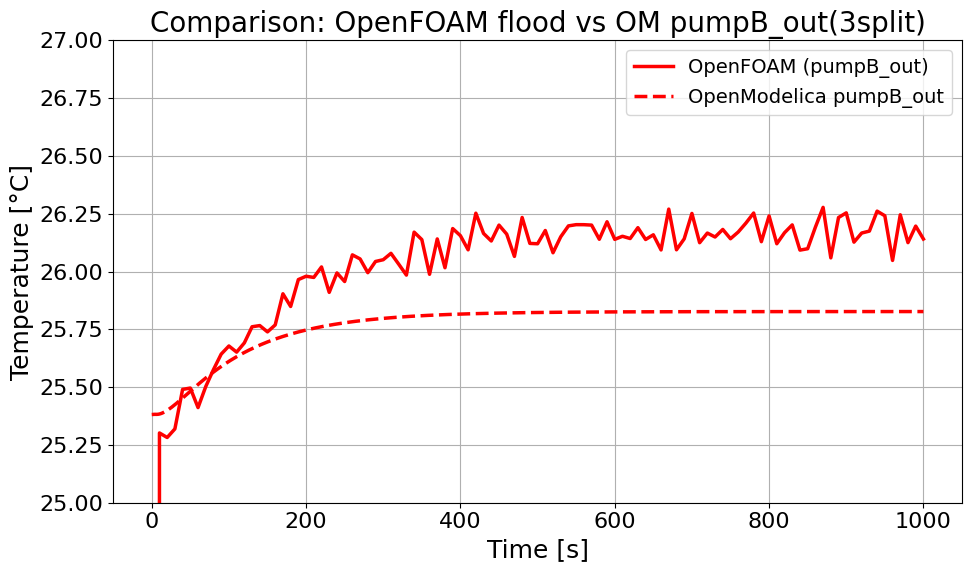

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

root = Path("./postProcessing")
om_csv = Path("./OM_csv/exportedVariables_3split.csv")

# ===== OpenFOAM（flood）を探す =====
dirs = sorted(root.glob("surfaceFieldValue_*"))
target_dir = next((d for d in dirs if "flood" in d.name.lower()), None)

if target_dir is None:
    raise ValueError("flood の surfaceFieldValue_* が見つかりませんでした！")

print(f"比較対象（OpenFOAM）：{target_dir.name}")

# ===== OpenFOAM 読み込み =====
foam_file = target_dir / "1000" / "surfaceFieldValue.dat"
df_foam = pd.read_csv(foam_file, comment="#", delim_whitespace=True, header=None)
df_foam.columns = ["time", "T"]
df_foam["T_C"] = df_foam["T"] - 273.15

# ===== OM 読み込み =====
df_om = pd.read_csv(om_csv)

col_om = "T_pumpB_out.T"
if col_om not in df_om.columns:
    raise ValueError(f"CSVに {col_om} がありません。列名を確認してください。")

# ===== Plot =====
plt.figure(figsize=(10, 6))

plt.plot(df_foam["time"], df_foam["T_C"], label="OpenFOAM (pumpB_out)",
         color="red", linewidth=2.5)

plt.plot(df_om["time"], df_om[col_om], label="OpenModelica pumpB_out",
         color="red", linestyle="--", linewidth=2.5)

plt.xlabel("Time [s]")
plt.ylabel("Temperature [°C]")
plt.title("Comparison: OpenFOAM flood vs OM pumpB_out(3split)")
plt.grid(True)

plt.ylim(25, 27)
plt.yticks([25 + 0.25*i for i in range(int((27-25)/0.25) + 1)])

plt.legend()
plt.tight_layout()
plt.show()


比較対象（OpenFOAM）：surfaceFieldValue_floodOutlet_press_2-4_0


C:\Users\kusum\AppData\Local\Temp\ipykernel_40488\2377883537.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_foam = pd.read_csv(foam_file, comment="#", delim_whitespace=True, header=None)


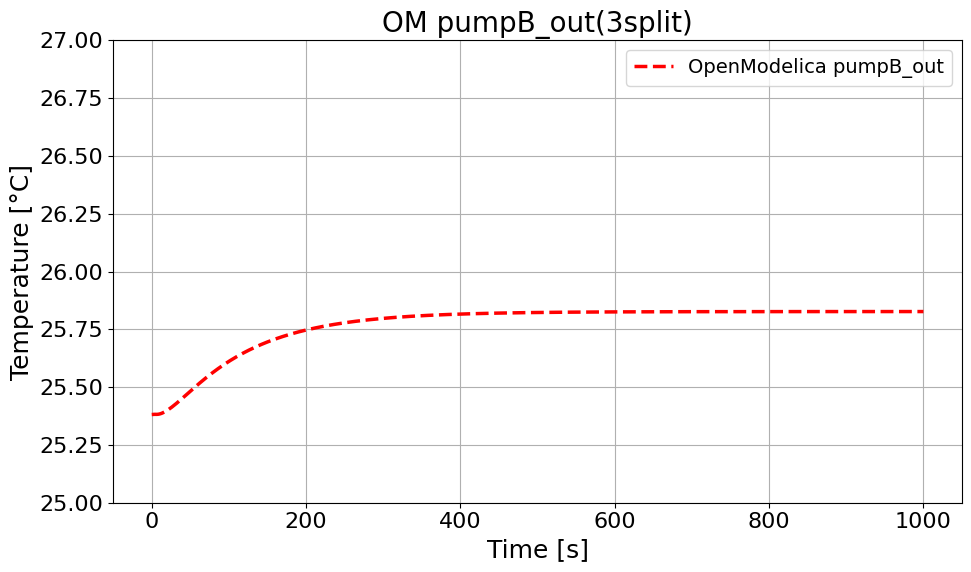

: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

root = Path("./postProcessing")
om_csv = Path("./OM_csv/exportedVariables_3split.csv")

# ===== OpenFOAM（flood）を探す =====
dirs = sorted(root.glob("surfaceFieldValue_*"))
target_dir = next((d for d in dirs if "flood" in d.name.lower()), None)

if target_dir is None:
    raise ValueError("flood の surfaceFieldValue_* が見つかりませんでした！")

print(f"比較対象（OpenFOAM）：{target_dir.name}")

# ===== OpenFOAM 読み込み =====
foam_file = target_dir / "1000" / "surfaceFieldValue.dat"
df_foam = pd.read_csv(foam_file, comment="#", delim_whitespace=True, header=None)
df_foam.columns = ["time", "T"]
df_foam["T_C"] = df_foam["T"] - 273.15

# ===== OM 読み込み =====
df_om = pd.read_csv(om_csv)

col_om = "T_pumpB_out.T"
if col_om not in df_om.columns:
    raise ValueError(f"CSVに {col_om} がありません。列名を確認してください。")

# ===== Plot =====
plt.figure(figsize=(10, 6))

# plt.plot(df_foam["time"], df_foam["T_C"], label="OpenFOAM (pumpB_out)",
#          color="red", linewidth=2.5)

plt.plot(df_om["time"], df_om[col_om], label="OpenModelica pumpB_out",
         color="red", linestyle="--", linewidth=2.5)

plt.xlabel("Time [s]")
plt.ylabel("Temperature [°C]")
plt.title("OM pumpB_out(3split)")
plt.grid(True)

plt.ylim(25, 27)
plt.yticks([25 + 0.25*i for i in range(int((27-25)/0.25) + 1)])

plt.legend()
plt.tight_layout()
plt.show()
